# 100 / 200 DMA Golden-Cross System — Indian Equities

**Rule.** Long when `SMA(100) > SMA(200)`, flat when `SMA(100) < SMA(200)`. Signal is read on
today's close and executed at **tomorrow's open** (no look-ahead). Every entry and exit pays a
cost. No leverage, no shorting, one position per name.

**What this notebook contains**

| § | Section |
|---|---|
| 1–2 | Config & data (Yahoo Finance, 5 NSE large/mid caps + Nifty 50) |
| 3 | Backtest engine — open-execution accounting, costs, trade ledger |
| 4 | Per-stock results: strategy vs buy & hold |
| 5 | Charts: signal maps, equity curves, drawdowns, risk/return |
| 6 | **Why the *D*MA (simple average) and not an EMA / WMA** — argued *and* tested |
| 7 | Equal-weight 5-stock portfolio vs buy & hold vs Nifty 50 |
| 8 | **Buy & hold vs the NIFTY 50** — alpha, beta, capture, and who actually beat the index |
| 9 | **Screener** — scan the whole NSE + BSE cash universe for live / fresh golden crosses |
| 10 | Honest caveats |

Run top-to-bottom. Everything is cached to disk, so a second run is fast.

## 0 · Setup

In [1]:
import os, json, time, math, pickle, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import requests
import yfinance as yf

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, PercentFormatter, MultipleLocator
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 80)

# ---- design tokens (validated, colour-blind-safe categorical order) -------
C = {
    "surface":   "#fcfcfb",
    "ink":       "#0b0b0b",
    "ink_2":     "#52514e",
    "ink_muted": "#8a8880",
    "grid":      "#e4e3df",
    "s1_blue":   "#2a78d6",   # slot 1  -> Strategy
    "s2_orange": "#eb6834",   # slot 2  -> Buy & Hold
    "s3_aqua":   "#1baf7a",   # slot 3  -> Benchmark (Nifty 50)
    "s4_yellow": "#eda100",
    "s5_magenta":"#e87ba4",
    "s6_green":  "#008300",
    "s7_violet": "#4a3aa7",
    "s8_red":    "#e34948",
    "good":      "#1baf7a",
    "bad":       "#e34948",
}
# diverging ramp for signed magnitudes: red (-) <- neutral grey -> blue (+)
DIVERGING = LinearSegmentedColormap.from_list(
    "rd_bu", ["#8f2423", "#e34948", "#f5a3a2", "#f0efec", "#9ec5f4", "#2a78d6", "#0d366b"]
)
SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seq_bu", ["#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#104281"]
)

mpl.rcParams.update({
    "figure.facecolor":  C["surface"],
    "axes.facecolor":    C["surface"],
    "savefig.facecolor": C["surface"],
    "axes.edgecolor":    C["grid"],
    "axes.linewidth":    0.8,
    "axes.labelcolor":   C["ink_2"],
    "axes.titlecolor":   C["ink"],
    "axes.titlesize":    12,
    "axes.titleweight":  "bold",
    "axes.titlelocation": "left",
    "axes.titlepad":     10,
    "axes.labelsize":    9.5,
    "axes.grid":         True,
    "axes.axisbelow":    True,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "grid.color":        C["grid"],
    "grid.linewidth":    0.6,
    "text.color":        C["ink"],
    "xtick.color":       C["ink_2"],
    "ytick.color":       C["ink_2"],
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.frameon":    False,
    "legend.fontsize":   9.5,
    "lines.linewidth":   2.0,
    "lines.solid_capstyle": "round",
    "figure.dpi":        110,
    "savefig.dpi":       150,
    "savefig.bbox":      "tight",
    "font.size":         10,
})

xfmt = lambda v, _=None: (f"{v:,.0f}x" if v >= 1 else f"{v:.1f}x")

def log_money(ax, unit="x"):
    '''Log y-axis labelled in plain multiples - matplotlib's 6x10^0 default is unreadable.'''
    f = xfmt if unit == "x" else (lambda v, _=None: f"{v:,.0f}")
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(FuncFormatter(f))
    ax.yaxis.set_minor_locator(mpl.ticker.LogLocator(base=10, subs=(2, 3, 5), numticks=20))
    ax.yaxis.set_minor_formatter(FuncFormatter(f))
    ax.tick_params(axis="y", which="minor", labelsize=8, colors=C["ink_muted"])

def end_labels(ax, series_colors, min_px=14):
    '''Value label at the right end of each line, stacked apart so labels never collide.'''
    ax.figure.canvas.draw()
    items = sorted(series_colors, key=lambda sc: sc[0].iloc[-1])
    want  = [ax.transData.transform((0, s.iloc[-1]))[1] for s, _ in items]
    got, last = [], None
    for y in want:
        y = y if last is None or y - last >= min_px else last + min_px
        got.append(y); last = y
    dpi = ax.figure.dpi
    for (ser, colr), y0, y1 in zip(items, want, got):
        ax.annotate(f"{ser.iloc[-1]:,.1f}x", (ser.index[-1], ser.iloc[-1]),
                    xytext=(7, (y1 - y0) * 72.0 / dpi), textcoords="offset points",
                    color=colr, fontsize=9.5, weight="bold", va="center")

pct  = lambda x, _=None: f"{x*100:,.0f}%"
pct1 = lambda x, _=None: f"{x*100:,.1f}%"

def finish(fig, note=None):
    '''Recessive footnote + tight layout, applied to every figure.'''
    if note:
        fig.text(0.005, -0.015, note, fontsize=8, color=C["ink_muted"], va="top")
    fig.tight_layout()
    return fig

print("pandas", pd.__version__, "| yfinance", yf.__version__, "| matplotlib", mpl.__version__)

pandas 3.0.5 | yfinance 1.7.0 | matplotlib 3.11.1


## 1 · Configuration

In [2]:
# ------------------------------- the universe under test --------------------
STOCKS = {
    "RELIANCE.NS":  "Reliance Industries",
    "TCS.NS":       "Tata Consultancy Services",
    "HDFCBANK.NS":  "HDFC Bank",
    "ITC.NS":       "ITC",
    "TATASTEEL.NS": "Tata Steel",
}
BENCHMARK = "^NSEI"          # Nifty 50 (Yahoo history starts 17-Sep-2007)

# ------------------------------- strategy parameters ------------------------
FAST, SLOW      = 100, 200   # the two simple moving averages, in trading days
COST_BPS        = 10         # per side: brokerage + STT + stamp + slippage (0.10%)
RF_ANNUAL       = 0.06       # risk-free for Sharpe / Sortino (Indian T-bill ~6%)
CASH_YIELD      = 0.00       # annual yield earned while flat. 0 = cash under mattress.

DOWNLOAD_START  = "2005-01-01"   # extra history so the 200-DMA is warm at the start
BACKTEST_START  = "2007-09-17"   # first day Nifty 50 data exists -> like-for-like vs benchmark

# ------------------------------- screener parameters ------------------------
MIN_MCAP_CR     = 1000       # rupees crore, from the BSE master list
MIN_TURNOVER_CR = 1.0        # median 60-day traded value, rupees crore
FRESH_DAYS      = 15         # a cross is "fresh" if it happened within N trading days
SCREEN_CHUNK    = 100        # tickers per Yahoo request
MAX_SCREEN      = None       # set e.g. 300 for a quick test run; None = whole universe

# ------------------------------- paths --------------------------------------
BASE   = Path.cwd()
DATA   = BASE / "data";   DATA.mkdir(exist_ok=True)
CHARTS = BASE / "charts"; CHARTS.mkdir(exist_ok=True)
OUT    = BASE / "output"; OUT.mkdir(exist_ok=True)

TICKERS = list(STOCKS) + [BENCHMARK]
print(f"{len(STOCKS)} stocks + benchmark | SMA {FAST}/{SLOW} | cost {COST_BPS} bps per side")
print("working dir:", BASE)

5 stocks + benchmark | SMA 100/200 | cost 10 bps per side
working dir: /Users/shivam/My projects/Option Strategy/Black Schole Method/dma_crossover_100_200


## 2 · Data

Adjusted OHLC from Yahoo Finance (`auto_adjust=True` → splits *and* dividends folded into the
price, so a buy-and-hold comparison is total-return honest). Cached to `data/` — delete the
pickle to force a refresh.

In [3]:
def load_prices(tickers, start=DOWNLOAD_START, cache_name="core_prices.pkl", max_age_h=12):
    '''Download adjusted OHLCV for a list of tickers, with a simple disk cache.'''
    f = DATA / cache_name
    if f.exists() and (time.time() - f.stat().st_mtime) < max_age_h * 3600:
        px = pickle.loads(f.read_bytes())
        if set(tickers).issubset(set(px.columns.get_level_values(1))):
            print(f"cache hit -> {f.name}")
            return px
    px = yf.download(tickers, start=start, auto_adjust=True, progress=False,
                     group_by="column", threads=True)
    px = px.dropna(how="all")
    f.write_bytes(pickle.dumps(px))
    print(f"downloaded {px.shape[0]} rows x {len(tickers)} tickers -> cached")
    return px

PX = load_prices(TICKERS)

def frame(ticker):
    '''Tidy OHLCV frame for one ticker.'''
    df = pd.DataFrame({k: PX[k][ticker] for k in ["Open", "High", "Low", "Close", "Volume"]})
    return df.dropna(subset=["Close"])

coverage = pd.DataFrame({
    "name":  [STOCKS.get(t, "NIFTY 50 index") for t in TICKERS],
    "from":  [frame(t).index[0].date()  for t in TICKERS],
    "to":    [frame(t).index[-1].date() for t in TICKERS],
    "bars":  [len(frame(t))             for t in TICKERS],
    "last":  [round(frame(t)["Close"].iloc[-1], 2) for t in TICKERS],
}, index=TICKERS)
display(coverage)

cache hit -> core_prices.pkl


,name,from,to,bars,last
RELIANCE.NS,Reliance Industries,2005-01-03,2026-09-18,5364,1226.40
TCS.NS,Tata Consultancy Services,2005-01-03,2026-09-18,5364,2105.00
HDFCBANK.NS,HDFC Bank,2005-01-03,2026-09-18,5364,731.00
ITC.NS,ITC,2005-01-03,2026-09-18,5364,262.30
TATASTEEL.NS,Tata Steel,2005-01-03,2026-09-18,5364,185.54
^NSEI,NIFTY 50 index,2007-09-17,2026-09-18,4663,23346.40


## 3 · The backtest engine

**Timing.** `SMA100 > SMA200` is evaluated on the close of day *t*. The position is entered at
the **open of day t+1**. So `position[t] = signal[t-1]`, and the day you enter you only earn
open→close, not the whole bar. That one detail is where most crossover backtests quietly leak
alpha, so it is handled explicitly:

| day type | return captured |
|---|---|
| entry day | `Close / Open − 1` |
| held day | `Close / Close₋₁ − 1` |
| exit day | `Open / Close₋₁ − 1` |
| flat day | `CASH_YIELD / 252` |

Costs of `COST_BPS` are charged on the entry day and again on the exit day.

In [4]:
def moving_average(close, n, kind="sma"):
    '''sma = the "n-DMA" every Indian chart quotes; ema/wma are the front-weighted variants.'''
    if kind == "sma":
        return close.rolling(n, min_periods=n).mean()
    if kind == "ema":
        e = close.ewm(span=n, adjust=False).mean()
        return e.where(close.rolling(n, min_periods=n).mean().notna())   # same warm-up
    if kind == "wma":
        w = np.arange(1, n + 1, dtype=float); w /= w.sum()
        return close.rolling(n, min_periods=n).apply(lambda x: float(np.dot(x, w)), raw=True)
    raise ValueError(kind)

def moving_averages(close, fast=FAST, slow=SLOW, kind="sma"):
    return moving_average(close, fast, kind), moving_average(close, slow, kind)

def signal_and_position(df, fast=FAST, slow=SLOW, kind="sma"):
    '''signal = desired exposure decided on today's close; position = what we actually hold.'''
    ma_f, ma_s = moving_averages(df["Close"], fast, slow, kind)
    sig = (ma_f > ma_s).astype("float64")
    sig[ma_s.isna() | ma_f.isna()] = np.nan          # no signal until both MAs exist
    pos = sig.shift(1)                               # traded at next open
    return ma_f, ma_s, sig, pos

def strategy_returns(df, pos, cost_bps=COST_BPS, cash_yield=CASH_YIELD):
    '''Daily net return of the rule, with open-execution and per-side costs.'''
    o, c = df["Open"], df["Close"]
    p     = pos.fillna(0.0)
    prev  = p.shift(1).fillna(0.0)

    r_hold  = c / c.shift(1) - 1.0     # in all day
    r_entry = c / o - 1.0              # bought at today's open
    r_exit  = o / c.shift(1) - 1.0     # sold at today's open
    r_cash  = cash_yield / 252.0

    r = pd.Series(r_cash, index=df.index, dtype="float64")
    r[(p == 1) & (prev == 1)] = r_hold[(p == 1) & (prev == 1)]
    r[(p == 1) & (prev == 0)] = r_entry[(p == 1) & (prev == 0)]
    r[(p == 0) & (prev == 1)] = r_exit[(p == 0) & (prev == 1)]

    turns = (p != prev).astype(float)                # 1 on every entry and every exit
    r = r - turns * (cost_bps / 1e4)
    return r.fillna(0.0), turns

def buy_hold_returns(df, cost_bps=COST_BPS):
    r = (df["Close"] / df["Close"].shift(1) - 1.0).fillna(0.0)
    r.iloc[0] -= cost_bps / 1e4                      # one entry ticket, for fairness
    return r

def trade_ledger(df, pos, cost_bps=COST_BPS, start=None):
    '''Round-trip ledger: entry/exit at the open, net of both tickets.'''
    o, c = df["Open"], df["Close"]
    p = pos.fillna(0.0)
    if start is not None:
        p, o, c = p.loc[start:], o.loc[start:], c.loc[start:]
    chg = p.diff()
    if len(p):
        chg.iloc[0] = p.iloc[0]
    entries, exits = p.index[chg == 1], p.index[chg == -1]
    k = cost_bps / 1e4
    rows = []
    for e in entries:
        later = exits[exits > e]
        if len(later):
            xd, xp, live = later[0], o.loc[later[0]], False
        else:
            xd, xp, live = p.index[-1], c.iloc[-1], True
        ep    = o.loc[e]
        gross = xp / ep - 1.0
        net   = (1 + gross) * (1 - k) ** 2 - 1.0
        rows.append(dict(entry=e, exit=xd, days=int((xd - e).days),
                         bars=int(p.loc[e:xd].shape[0]),
                         entry_px=round(ep, 2), exit_px=round(xp, 2),
                         gross=gross, net=net, open_trade=live))
    return pd.DataFrame(rows)

def equity(returns):
    return (1.0 + returns).cumprod()

def drawdown(eq):
    return eq / eq.cummax() - 1.0

def perf_stats(r, rf=RF_ANNUAL, periods=252, exposure=None):
    r  = r.dropna()
    eq = equity(r)
    yrs = len(r) / periods
    total = eq.iloc[-1] - 1.0
    cagr  = eq.iloc[-1] ** (1 / yrs) - 1.0
    vol   = r.std() * np.sqrt(periods)
    ann   = r.mean() * periods
    down  = r[r < 0].std() * np.sqrt(periods)
    dd    = drawdown(eq)
    mdd   = dd.min()
    # longest stretch below the previous peak
    under = (dd < 0).astype(int)
    grp   = (under.diff() != 0).cumsum()
    longest = int(under.groupby(grp).sum().max()) if len(under) else 0
    m = (1 + r).resample("ME").prod() - 1
    return {
        "Total return":  total,
        "CAGR":          cagr,
        "Ann. vol":      vol,
        "Sharpe":        (ann - rf) / vol if vol else np.nan,
        "Sortino":       (ann - rf) / down if down else np.nan,
        "Max DD":        mdd,
        "Calmar":        cagr / abs(mdd) if mdd else np.nan,
        "Longest DD (d)": longest,
        "Best month":    m.max(),
        "Worst month":   m.min(),
        "% up months":   (m > 0).mean(),
        "Time in mkt":   float(exposure) if exposure is not None else 1.0,
    }

print("engine ready")

engine ready


## 4 · Run the backtest on the five stocks

In [5]:
RES = {}
for t, name in STOCKS.items():
    df = frame(t)
    ma_f, ma_s, sig, pos = signal_and_position(df)
    r_s, turns = strategy_returns(df, pos)
    r_b        = buy_hold_returns(df)

    w = slice(BACKTEST_START, None)                       # evaluation window
    rs, rb, ps = r_s.loc[w], r_b.loc[w], pos.loc[w].fillna(0.0)
    rb.iloc[0] = (df["Close"].loc[w].iloc[0] / df["Open"].loc[w].iloc[0] - 1) - COST_BPS / 1e4

    RES[t] = {
        "name": name, "df": df, "ma_f": ma_f, "ma_s": ma_s, "pos": pos,
        "r_s": rs, "r_b": rb,
        "eq_s": equity(rs), "eq_b": equity(rb),
        "trades": trade_ledger(df, pos, start=BACKTEST_START),
        "stats_s": perf_stats(rs, exposure=ps.mean()),
        "stats_b": perf_stats(rb, exposure=1.0),
        "n_switch": int(turns.loc[w].sum()),
    }

# benchmark
bdf = frame(BENCHMARK)
r_n = (bdf["Close"] / bdf["Close"].shift(1) - 1).loc[BACKTEST_START:].fillna(0.0)
eq_n, stats_n = equity(r_n), perf_stats(r_n)

span = RES["RELIANCE.NS"]["r_s"]
print(f"window {span.index[0].date()} -> {span.index[-1].date()}  "
      f"({len(span)} bars, {len(span)/252:.1f} years)")
for t in STOCKS:
    n = len(RES[t]["trades"])
    print(f"  {t:<14} {n:>3} round trips   "
          f"strategy CAGR {RES[t]['stats_s']['CAGR']:6.2%}   "
          f"buy&hold CAGR {RES[t]['stats_b']['CAGR']:6.2%}")

window 2007-09-17 -> 2026-09-18  (4691 bars, 18.6 years)
  RELIANCE.NS     15 round trips   strategy CAGR  5.03%   buy&hold CAGR 10.14%
  TCS.NS          10 round trips   strategy CAGR 12.92%   buy&hold CAGR 14.51%
  HDFCBANK.NS     10 round trips   strategy CAGR 10.86%   buy&hold CAGR 15.25%
  ITC.NS           9 round trips   strategy CAGR 11.75%   buy&hold CAGR 11.74%
  TATASTEEL.NS    12 round trips   strategy CAGR 11.67%   buy&hold CAGR  9.86%


### 4.1 · Scorecard — strategy vs buy & hold

In [6]:
def scorecard():
    rows = []
    for t, R in RES.items():
        for tag, key in [("100/200 DMA", "stats_s"), ("Buy & hold", "stats_b")]:
            s = dict(R[key]); s["Stock"] = R["name"]; s["Approach"] = tag
            s["Trades"] = len(R["trades"]) if key == "stats_s" else 1
            rows.append(s)
    s = dict(stats_n); s["Stock"] = "NIFTY 50"; s["Approach"] = "Buy & hold"; s["Trades"] = 1
    rows.append(s)
    cols = ["Stock", "Approach", "Total return", "CAGR", "Ann. vol", "Sharpe", "Sortino",
            "Max DD", "Calmar", "Longest DD (d)", "% up months", "Time in mkt", "Trades"]
    return pd.DataFrame(rows)[cols]

SCORE = scorecard()
fmt = {"Total return": "{:,.0%}", "CAGR": "{:.2%}", "Ann. vol": "{:.2%}", "Sharpe": "{:.2f}",
       "Sortino": "{:.2f}", "Max DD": "{:.1%}", "Calmar": "{:.2f}", "% up months": "{:.0%}",
       "Time in mkt": "{:.0%}"}
display(SCORE.style.hide(axis="index").format(fmt)
        .set_caption(f"{BACKTEST_START} to {span.index[-1].date()} — net of {COST_BPS} bps per side"))

Stock,Approach,Total return,CAGR,Ann. vol,Sharpe,Sortino,Max DD,Calmar,Longest DD (d),% up months,Time in mkt,Trades
Reliance Industries,100/200 DMA,149%,5.03%,23.81%,0.07,0.09,-57.0%,0.09,2406,35%,67%,15
Reliance Industries,Buy & hold,504%,10.14%,31.30%,0.27,0.40,-68.2%,0.15,2331,53%,100%,1
Tata Consultancy Services,100/200 DMA,861%,12.92%,20.89%,0.40,0.51,-34.5%,0.37,776,40%,67%,10
Tata Consultancy Services,Buy & hold,"1,147%",14.51%,29.10%,0.40,0.59,-59.2%,0.24,513,55%,100%,1
HDFC Bank,100/200 DMA,582%,10.86%,20.87%,0.31,0.39,-41.1%,0.26,771,46%,75%,10
HDFC Bank,Buy & hold,"1,304%",15.25%,27.36%,0.44,0.62,-55.1%,0.28,452,58%,100%,1
ITC,100/200 DMA,691%,11.75%,21.68%,0.34,0.41,-39.8%,0.29,1059,44%,70%,9
ITC,Buy & hold,689%,11.74%,26.31%,0.33,0.46,-55.3%,0.21,1235,57%,100%,1
Tata Steel,100/200 DMA,681%,11.67%,27.92%,0.32,0.35,-52.3%,0.22,1777,34%,55%,12
Tata Steel,Buy & hold,475%,9.86%,41.26%,0.29,0.41,-83.7%,0.12,2460,51%,100%,1


### 4.2 · The head-to-head table

Positive = the rule beat holding the same stock.

In [7]:
delta = pd.DataFrame({
    "Stock":        [RES[t]["name"] for t in STOCKS],
    "CAGR Δ":       [RES[t]["stats_s"]["CAGR"]   - RES[t]["stats_b"]["CAGR"]   for t in STOCKS],
    "Sharpe Δ":     [RES[t]["stats_s"]["Sharpe"] - RES[t]["stats_b"]["Sharpe"] for t in STOCKS],
    "Max DD Δ":     [RES[t]["stats_s"]["Max DD"] - RES[t]["stats_b"]["Max DD"] for t in STOCKS],
    "Vol Δ":        [RES[t]["stats_s"]["Ann. vol"] - RES[t]["stats_b"]["Ann. vol"] for t in STOCKS],
    "Time in mkt":  [RES[t]["stats_s"]["Time in mkt"] for t in STOCKS],
    "Round trips":  [len(RES[t]["trades"]) for t in STOCKS],
})
display(delta.style.hide(axis="index").format(
    {"CAGR Δ": "{:+.2%}", "Sharpe Δ": "{:+.2f}", "Max DD Δ": "{:+.1%}",
     "Vol Δ": "{:+.2%}", "Time in mkt": "{:.0%}"})
    .set_caption("Δ = strategy − buy & hold.  Max DD Δ positive means a shallower hole."))

Stock,CAGR Δ,Sharpe Δ,Max DD Δ,Vol Δ,Time in mkt,Round trips
Reliance Industries,-5.11%,-0.20,+11.1%,-7.49%,67%,15
Tata Consultancy Services,-1.59%,-0.01,+24.7%,-8.20%,67%,10
HDFC Bank,-4.38%,-0.12,+14.1%,-6.49%,75%,10
ITC,+0.01%,+0.02,+15.4%,-4.63%,70%,9
Tata Steel,+1.82%,+0.03,+31.4%,-13.34%,55%,12


## 5 · Charts

### 5.1 · Signal map — price, the two averages, and every trade
Shaded bands are the periods the system was long. Log price axis so early and late years are
equally readable.

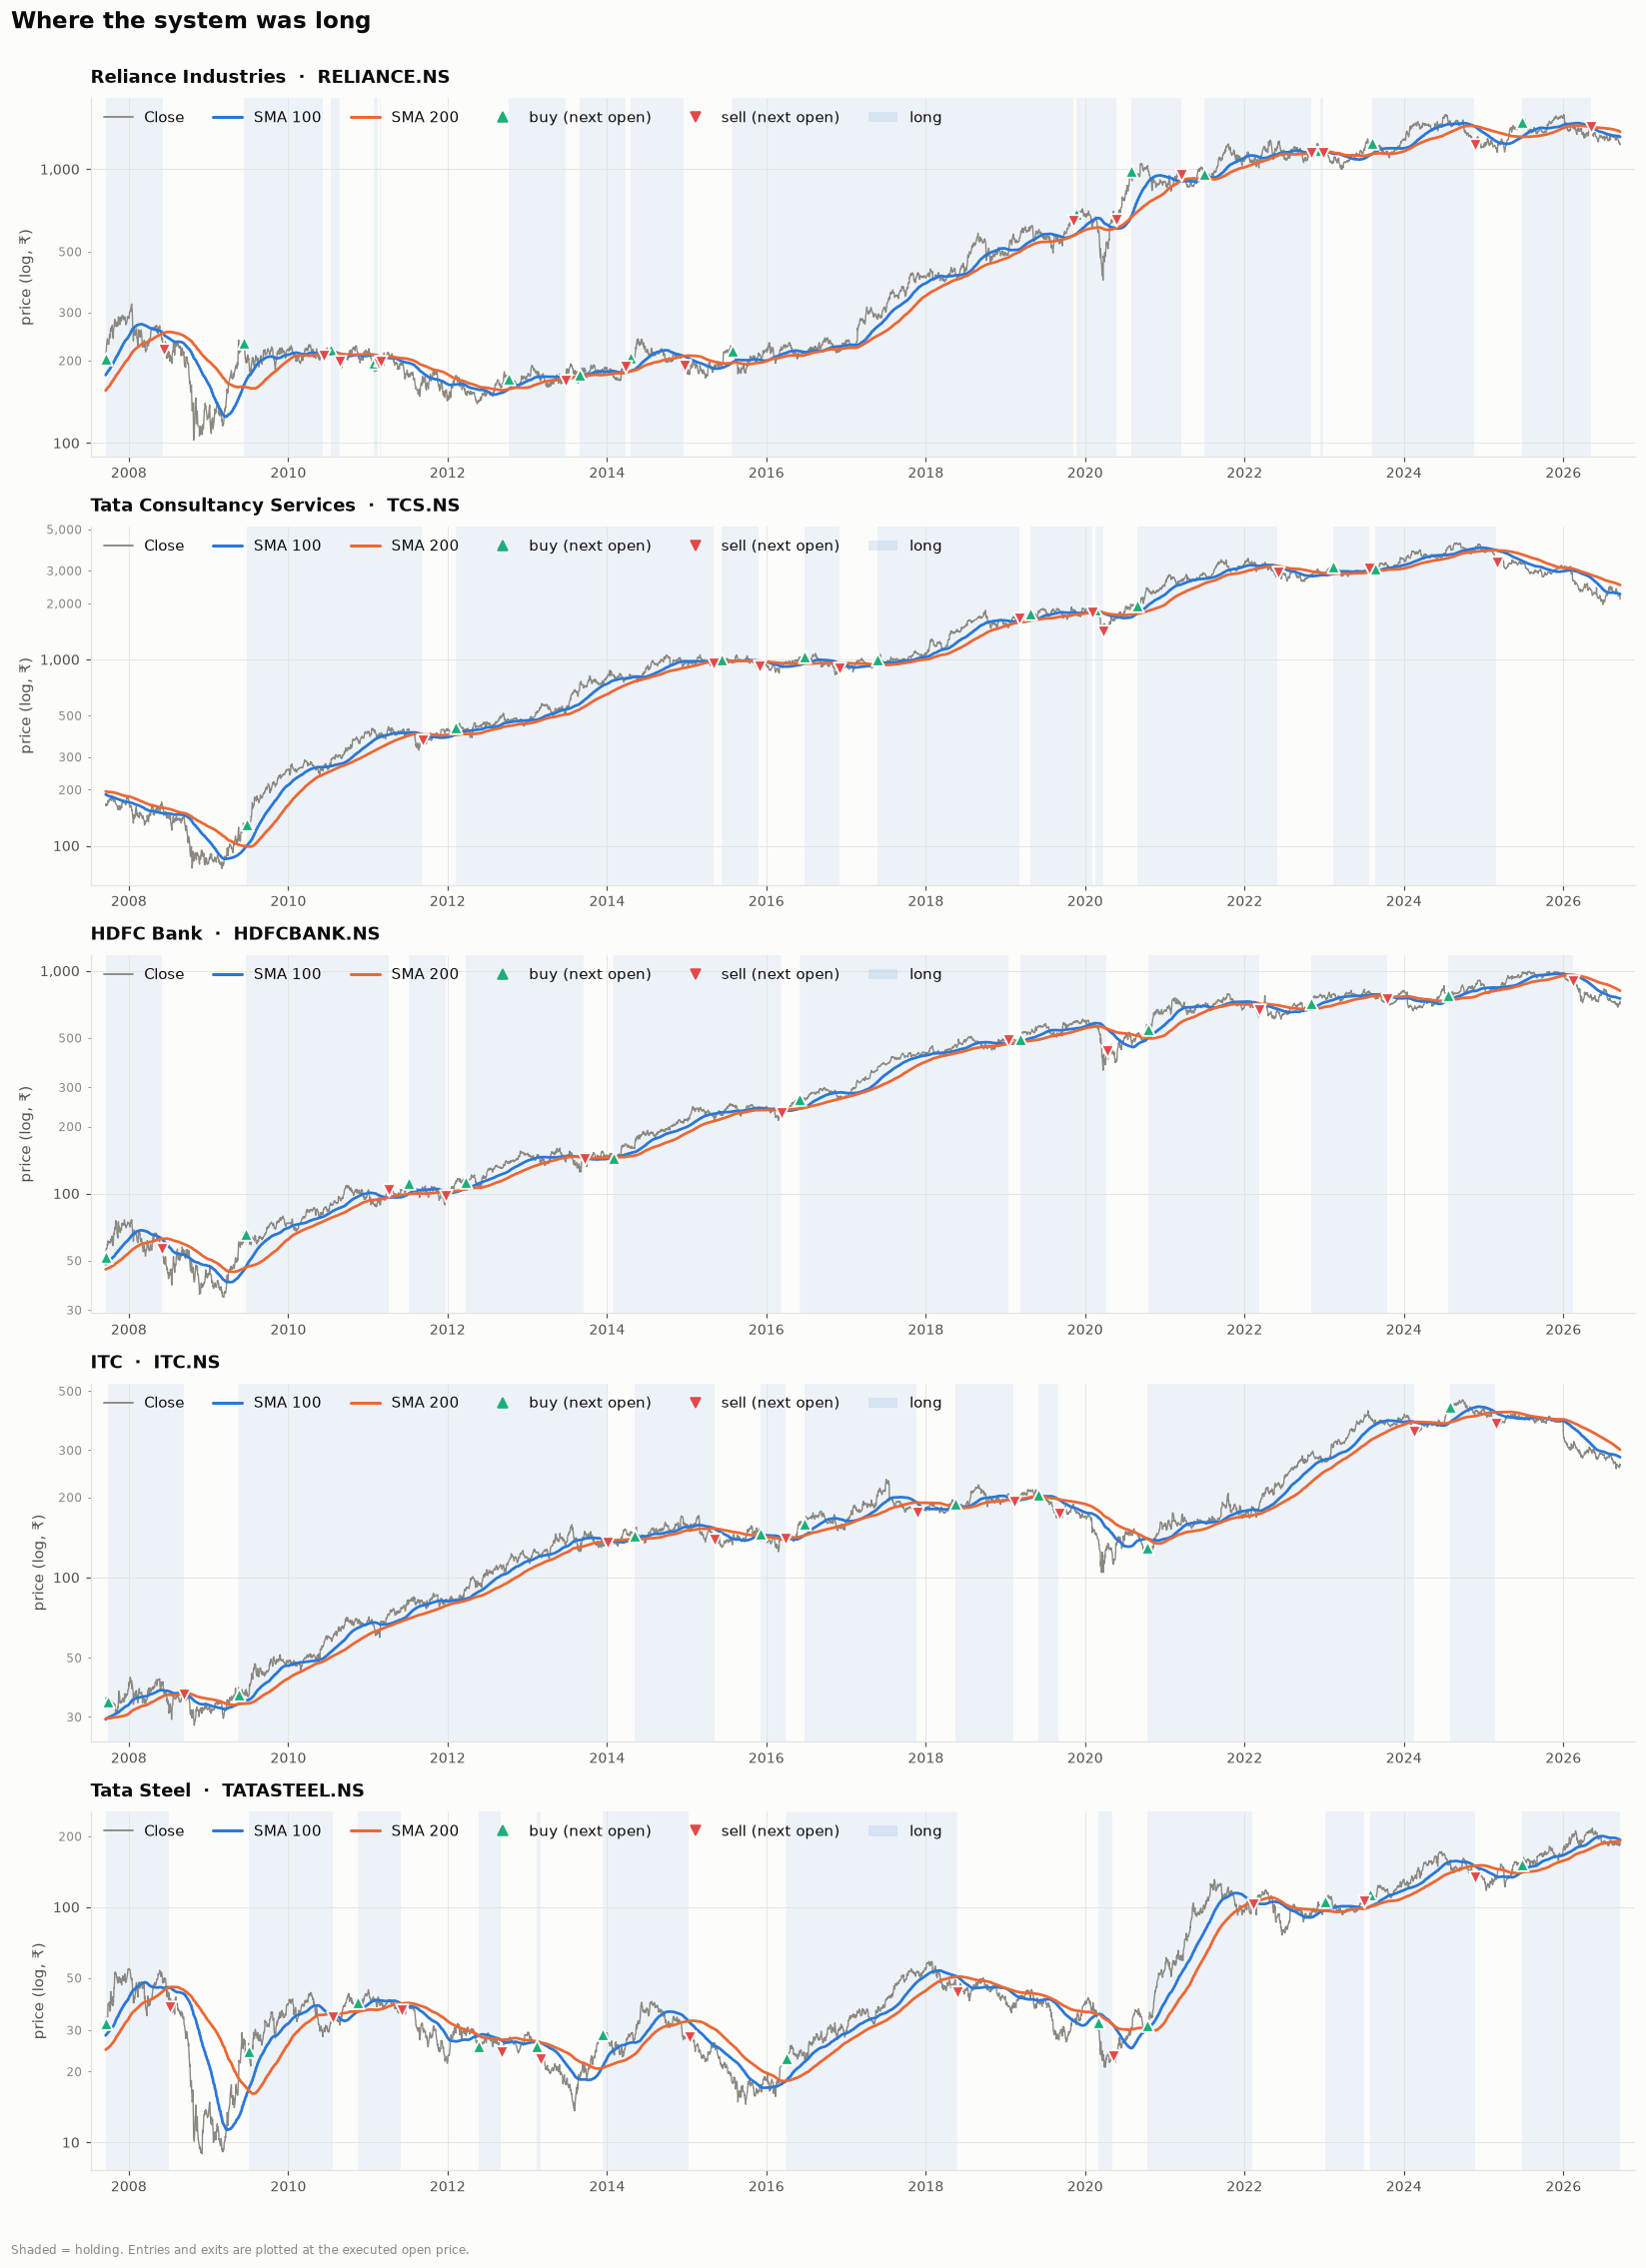

In [8]:
fig, axes = plt.subplots(len(STOCKS), 1, figsize=(15, 4.0 * len(STOCKS)), sharex=False)
for ax, (t, R) in zip(np.atleast_1d(axes), RES.items()):
    d  = R["df"].loc[BACKTEST_START:]
    mf = R["ma_f"].loc[BACKTEST_START:]
    ms = R["ma_s"].loc[BACKTEST_START:]
    p  = R["pos"].loc[BACKTEST_START:].fillna(0)

    ax.fill_between(d.index, 0, 1, where=(p == 1), transform=ax.get_xaxis_transform(),
                    color=C["s1_blue"], alpha=0.07, lw=0, zorder=0)
    ax.plot(d.index, d["Close"], color=C["ink_muted"], lw=0.9, label="Close", zorder=2)
    ax.plot(mf.index, mf, color=C["s1_blue"],   lw=1.8, label=f"SMA {FAST}", zorder=3)
    ax.plot(ms.index, ms, color=C["s2_orange"], lw=1.8, label=f"SMA {SLOW}", zorder=3)

    tr = R["trades"]
    if len(tr):
        ax.scatter(tr["entry"], tr["entry_px"], marker="^", s=68, zorder=5,
                   color=C["good"], edgecolor=C["surface"], linewidth=1.2)
        closed = tr[~tr["open_trade"]]
        ax.scatter(closed["exit"], closed["exit_px"], marker="v", s=68, zorder=5,
                   color=C["bad"], edgecolor=C["surface"], linewidth=1.2)

    log_money(ax, unit="rs")
    ax.set_title(f"{R['name']}  ·  {t}", loc="left")
    ax.set_ylabel("price (log, ₹)")
    ax.margins(x=0.01)
    hs = [Line2D([], [], color=C["ink_muted"], lw=1.2, label="Close"),
          Line2D([], [], color=C["s1_blue"],   lw=2, label=f"SMA {FAST}"),
          Line2D([], [], color=C["s2_orange"], lw=2, label=f"SMA {SLOW}"),
          Line2D([], [], color=C["good"], marker="^", ls="", label="buy (next open)"),
          Line2D([], [], color=C["bad"],  marker="v", ls="", label="sell (next open)"),
          Patch(facecolor=C["s1_blue"], alpha=0.12, label="long")]
    ax.legend(handles=hs, ncols=6, loc="upper left", bbox_to_anchor=(0, 1.0))
fig.suptitle("Where the system was long", x=0.005, ha="left", fontsize=15, weight="bold", y=1.001)
finish(fig, "Shaded = holding. Entries and exits are plotted at the executed open price.")
fig.savefig(CHARTS / "01_signal_map.png")
plt.show()

### 5.2 · Growth of ₹1 — strategy vs buy & hold

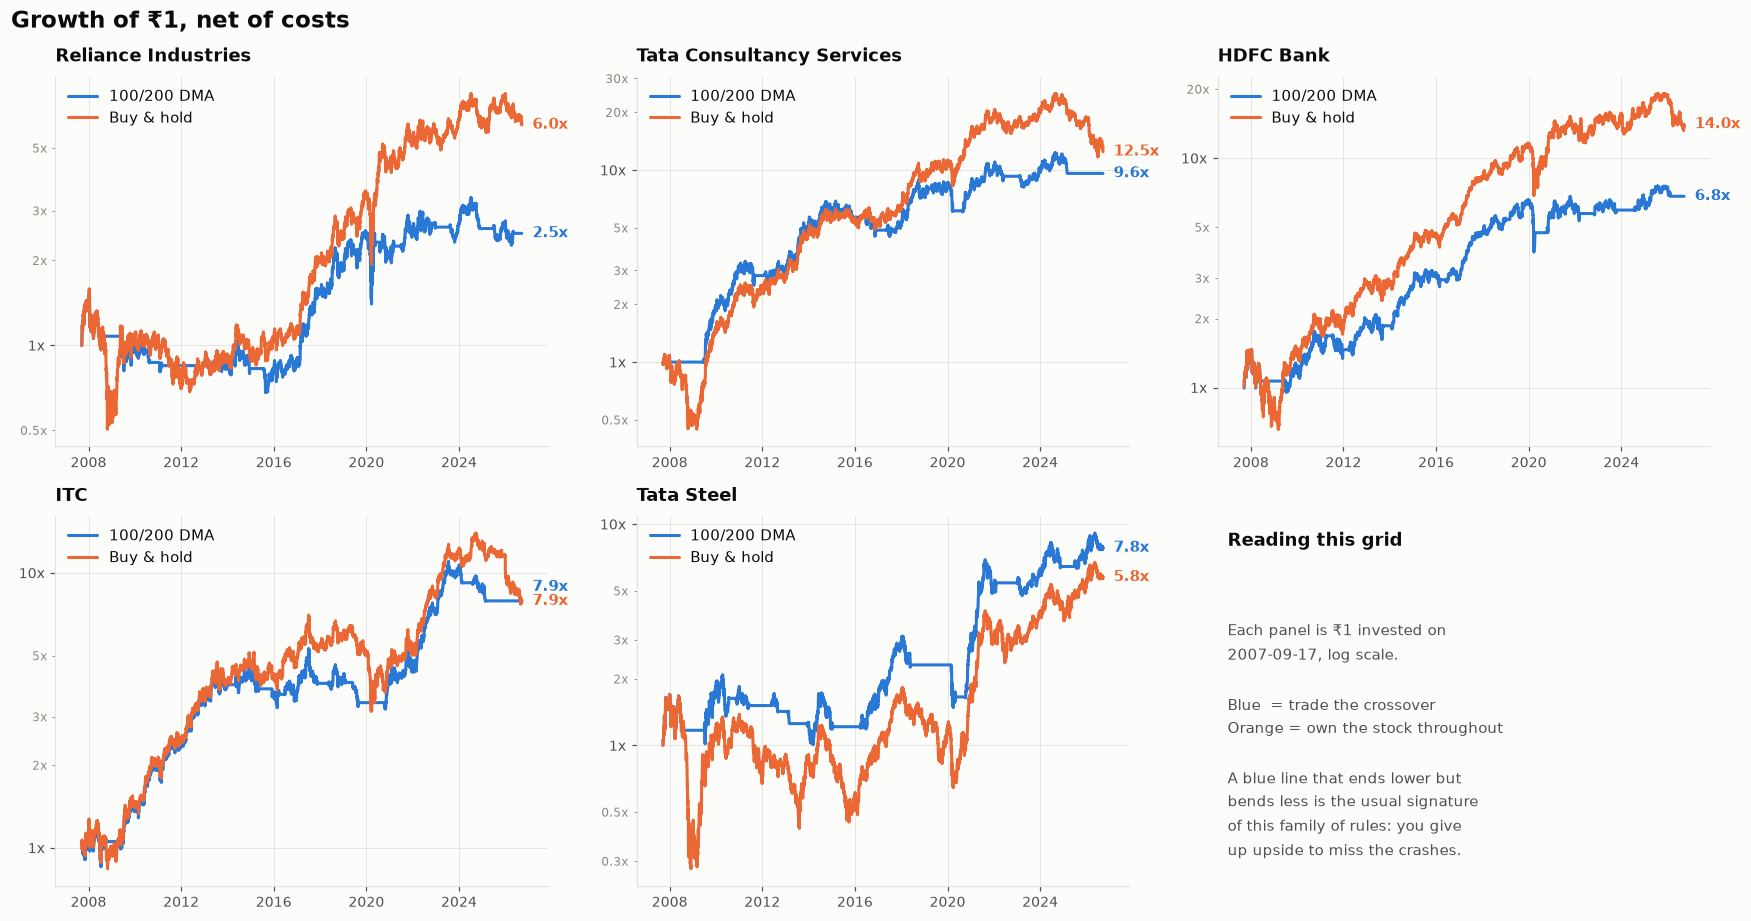

In [9]:
n = len(STOCKS)
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
axes = axes.ravel()
for ax, (t, R) in zip(axes, RES.items()):
    ax.plot(R["eq_s"].index, R["eq_s"], color=C["s1_blue"],   label="100/200 DMA")
    ax.plot(R["eq_b"].index, R["eq_b"], color=C["s2_orange"], label="Buy & hold")
    log_money(ax)
    ax.set_title(R["name"], loc="left")
    ax.margins(x=0.06)
    end_labels(ax, [(R["eq_s"], C["s1_blue"]), (R["eq_b"], C["s2_orange"])])
    ax.legend(loc="upper left")
axes[-1].axis("off")
axes[-1].text(0.02, 0.92, "Reading this grid", fontsize=12, weight="bold", color=C["ink"])
axes[-1].text(0.02, 0.06,
    "Each panel is ₹1 invested on\n"
    f"{BACKTEST_START}, log scale.\n\n"
    "Blue  = trade the crossover\n"
    "Orange = own the stock throughout\n\n"
    "A blue line that ends lower but\n"
    "bends less is the usual signature\n"
    "of this family of rules: you give\n"
    "up upside to miss the crashes.",
    fontsize=10, color=C["ink_2"], va="bottom", linespacing=1.6)
fig.suptitle("Growth of ₹1, net of costs", x=0.005, ha="left", fontsize=15, weight="bold")
finish(fig)
fig.savefig(CHARTS / "02_equity_curves.png")
plt.show()

### 5.3 · Underwater curves
The whole point of a trend filter is this chart, not the last one.

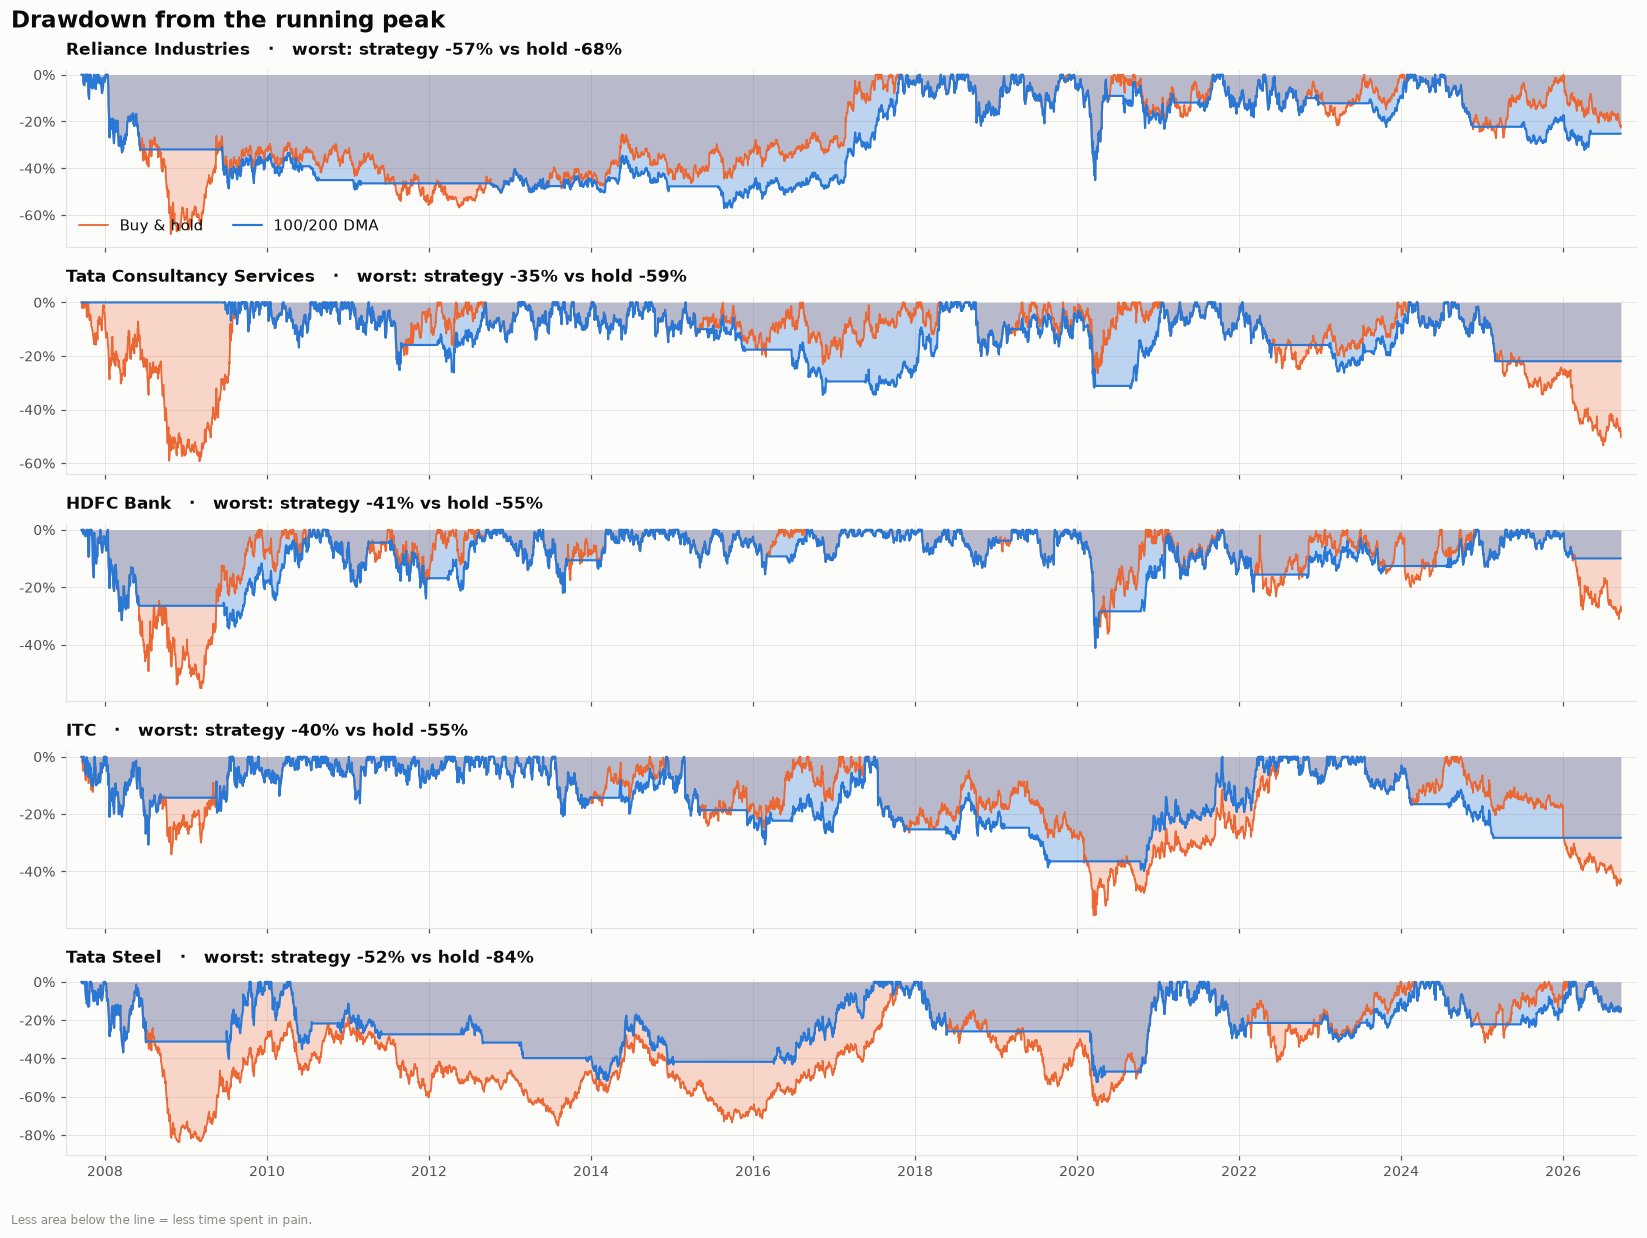

In [10]:
fig, axes = plt.subplots(len(STOCKS), 1, figsize=(15, 2.2 * len(STOCKS)), sharex=True)
for ax, (t, R) in zip(np.atleast_1d(axes), RES.items()):
    ds, db = drawdown(R["eq_s"]), drawdown(R["eq_b"])
    ax.fill_between(db.index, db, 0, color=C["s2_orange"], alpha=0.25, lw=0)
    ax.plot(db.index, db, color=C["s2_orange"], lw=1.2, label="Buy & hold")
    ax.fill_between(ds.index, ds, 0, color=C["s1_blue"], alpha=0.30, lw=0)
    ax.plot(ds.index, ds, color=C["s1_blue"], lw=1.4, label="100/200 DMA")
    ax.yaxis.set_major_formatter(FuncFormatter(pct))
    ax.set_ylim(min(ds.min(), db.min()) * 1.08, 0.02)
    ax.set_title(f"{R['name']}   ·   worst: strategy {ds.min():.0%} vs hold {db.min():.0%}",
                 loc="left", fontsize=11)
    ax.margins(x=0.01)
    if ax is np.atleast_1d(axes)[0]:
        ax.legend(ncols=2, loc="lower left")
fig.suptitle("Drawdown from the running peak", x=0.005, ha="left", fontsize=15, weight="bold")
finish(fig, "Less area below the line = less time spent in pain.")
fig.savefig(CHARTS / "03_drawdowns.png")
plt.show()

### 5.4 · Scorecard at a glance

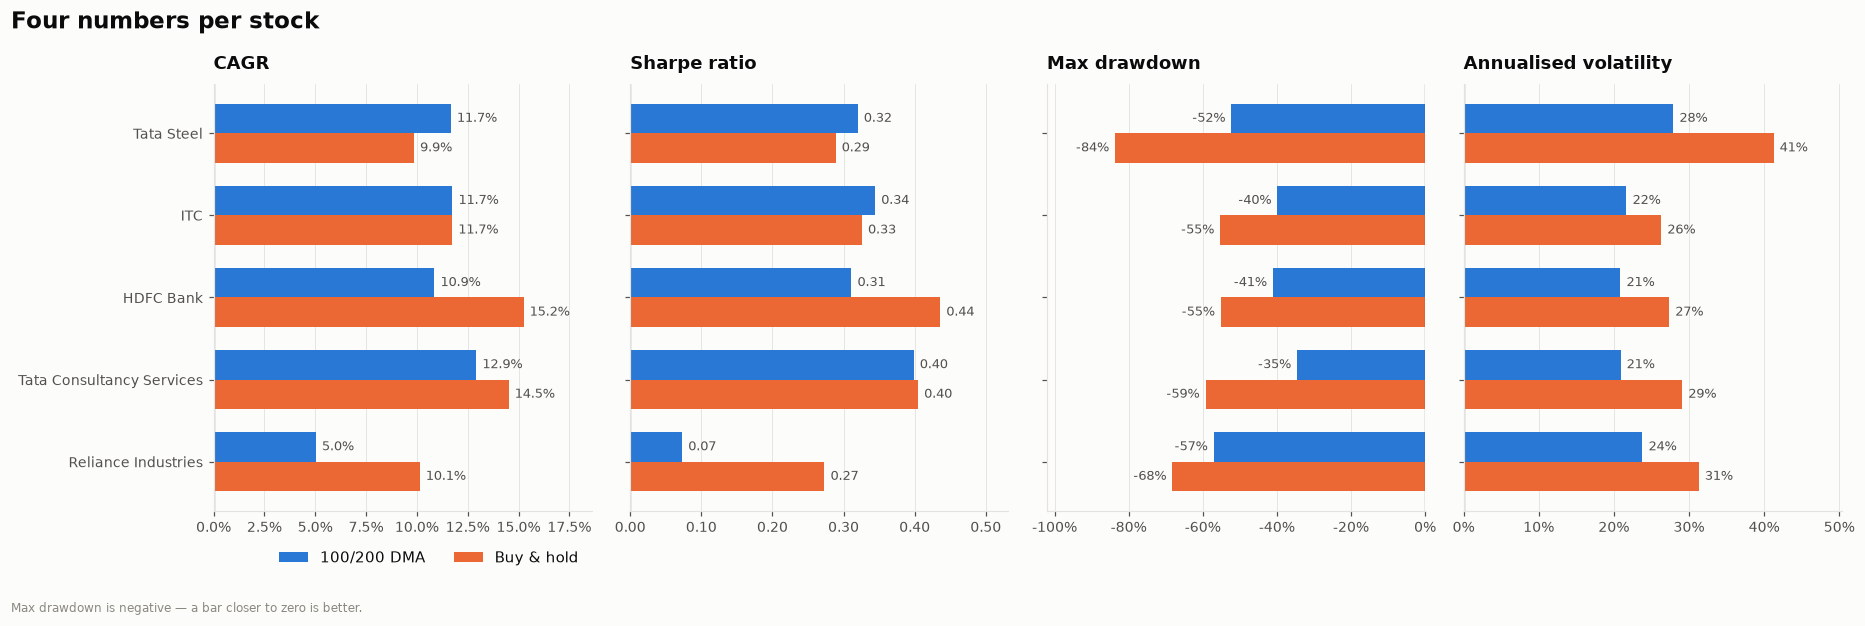

In [11]:
names  = [RES[t]["name"] for t in STOCKS]
y      = np.arange(len(names))
h      = 0.36
panels = [("CAGR", "CAGR", pct1, False),
          ("Sharpe ratio", "Sharpe", lambda v, _=None: f"{v:.2f}", False),
          ("Max drawdown", "Max DD", pct, True),
          ("Annualised volatility", "Ann. vol", pct, False)]

fig, axes = plt.subplots(1, 4, figsize=(17, 5.4))
for ax, (title, key, f, invert) in zip(axes, panels):
    s = [RES[t]["stats_s"][key] for t in STOCKS]
    b = [RES[t]["stats_b"][key] for t in STOCKS]
    ax.barh(y + h/2, s, height=h, color=C["s1_blue"],   label="100/200 DMA")
    ax.barh(y - h/2, b, height=h, color=C["s2_orange"], label="Buy & hold")
    ax.set_yticks(y, names if ax is axes[0] else [""] * len(names))
    ax.axvline(0, color=C["ink_2"], lw=0.8)
    ax.xaxis.set_major_formatter(FuncFormatter(f))
    ax.set_title(title, loc="left")
    ax.grid(axis="y", visible=False)
    for vals, off in [(s, h/2), (b, -h/2)]:
        for yi, v in zip(y, vals):
            ax.annotate(f(v), (v, yi + off), xytext=(4 if v >= 0 else -4, 0),
                        textcoords="offset points", fontsize=8.5, color=C["ink_2"],
                        va="center", ha="left" if v >= 0 else "right")
    ax.margins(x=0.22)
axes[0].legend(ncols=2, loc="lower right", bbox_to_anchor=(1, -0.16))
fig.suptitle("Four numbers per stock", x=0.005, ha="left", fontsize=15, weight="bold")
finish(fig, "Max drawdown is negative — a bar closer to zero is better.")
fig.savefig(CHARTS / "04_metric_bars.png")
plt.show()

### 5.5 · Risk vs return
Each arrow starts at buy & hold and points to where the crossover rule moved that stock.
Up-and-left is the direction you want.

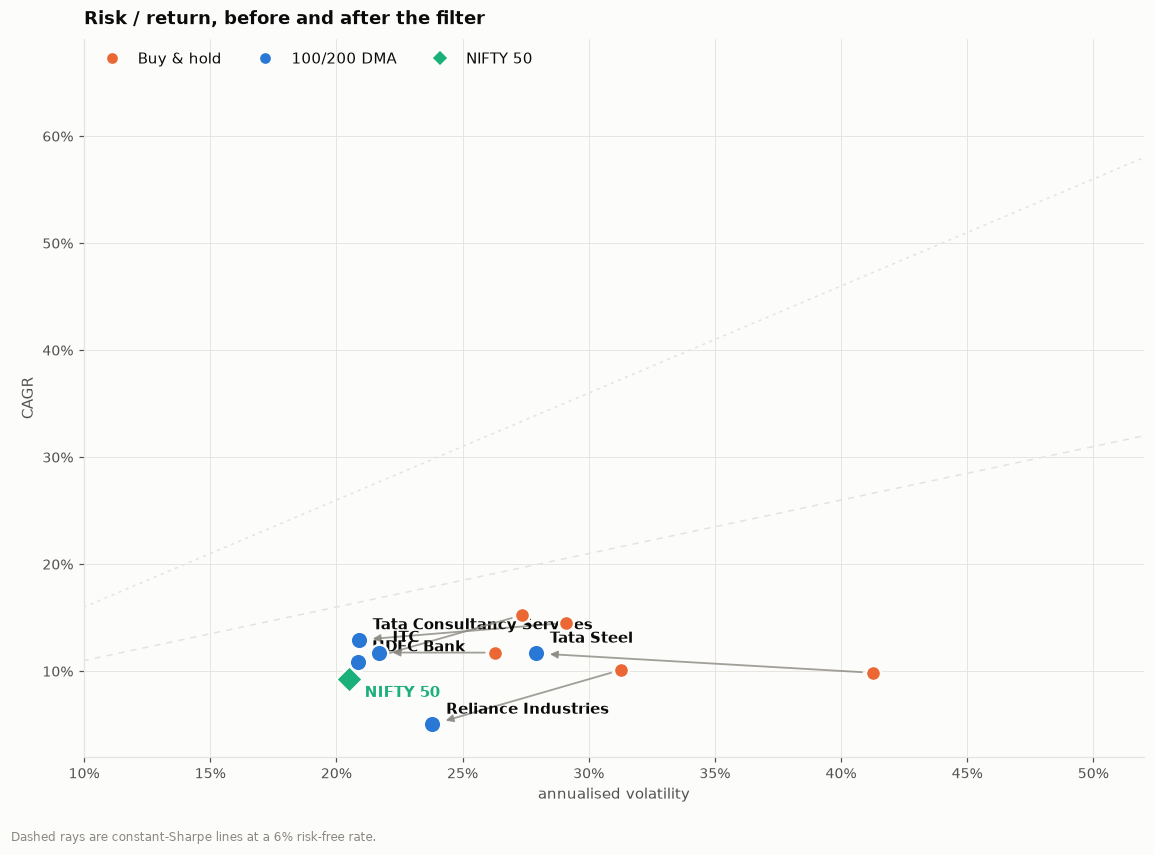

In [12]:
fig, ax = plt.subplots(figsize=(10.5, 7.5))
for t, R in RES.items():
    xb, yb = R["stats_b"]["Ann. vol"], R["stats_b"]["CAGR"]
    xs, ys = R["stats_s"]["Ann. vol"], R["stats_s"]["CAGR"]
    ax.annotate("", xy=(xs, ys), xytext=(xb, yb),
                arrowprops=dict(arrowstyle="-|>", color=C["ink_muted"], lw=1.2,
                                shrinkA=7, shrinkB=9, alpha=0.8))
    ax.scatter([xb], [yb], s=95, color=C["s2_orange"], edgecolor=C["surface"], lw=1.5, zorder=4)
    ax.scatter([xs], [ys], s=130, color=C["s1_blue"],  edgecolor=C["surface"], lw=1.5, zorder=5)
    ax.annotate(R["name"], (xs, ys), xytext=(9, 7), textcoords="offset points",
                fontsize=9.5, color=C["ink"], weight="bold")
ax.scatter([stats_n["Ann. vol"]], [stats_n["CAGR"]], s=150, marker="D",
           color=C["s3_aqua"], edgecolor=C["surface"], lw=1.5, zorder=6)
ax.annotate("NIFTY 50", (stats_n["Ann. vol"], stats_n["CAGR"]), xytext=(10, -12),
            textcoords="offset points", fontsize=9.5, color=C["s3_aqua"], weight="bold")

for sr, style in [(0.5, (0, (4, 4))), (1.0, (0, (2, 3)))]:
    xs_ = np.linspace(0.05, 0.60, 50)
    ax.plot(xs_, RF_ANNUAL + sr * xs_, color=C["grid"], lw=1, ls=style, zorder=1)
    ax.annotate(f"Sharpe {sr:g}", (xs_[-1], RF_ANNUAL + sr * xs_[-1]), xytext=(-2, 4),
                textcoords="offset points", fontsize=8.5, color=C["ink_muted"], ha="right")

ax.xaxis.set_major_formatter(FuncFormatter(pct)); ax.yaxis.set_major_formatter(FuncFormatter(pct))
ax.set_xlabel("annualised volatility"); ax.set_ylabel("CAGR")
ax.set_title("Risk / return, before and after the filter", loc="left")
ax.legend(handles=[Line2D([], [], marker="o", ls="", color=C["s2_orange"], label="Buy & hold"),
                   Line2D([], [], marker="o", ls="", color=C["s1_blue"],   label="100/200 DMA"),
                   Line2D([], [], marker="D", ls="", color=C["s3_aqua"],   label="NIFTY 50")],
          ncols=3, loc="upper left")
ax.set_xlim(0.10, 0.52)
finish(fig, f"Dashed rays are constant-Sharpe lines at a {RF_ANNUAL:.0%} risk-free rate.")
fig.savefig(CHARTS / "05_risk_return.png")
plt.show()

## 6 · Why the *D*MA — and not an EMA or WMA

**First, the terminology.** In Indian market usage "100 DMA" means *100-**D**ay Moving Average* —
the **D** is the sampling frequency (daily bars), not a different formula. A 100 DMA quoted on
NSE, by a broker, or on a TV ticker **is** the 100-period **simple** moving average of daily
closes. So "DMA vs SMA" is not a real choice; the real choice is:

$$\text{SMA}_n=\frac1n\sum_{i=0}^{n-1}P_{t-i}
\qquad
\text{EMA}_n=\alpha P_t+(1-\alpha)\text{EMA}_{n,t-1},\ \ \alpha=\tfrac{2}{n+1}
\qquad
\text{WMA}_n=\frac{\sum_{i=0}^{n-1}(n-i)P_{t-i}}{\sum_{i=1}^{n} i}$$

All three are low-pass filters. They differ only in how the weight is spread across the window.

### The six reasons this system uses the simple average

**1 · Equal weights are the right prior for a *regime* filter.**
A 100/200 crossover is not trying to time the next three days; it is asking *"has the average
price of the last five months moved above the average of the last ten?"* That question deserves
a flat weighting — every day in the lookback is equal evidence about the regime. An EMA puts
~2% of its weight on today's close, which is exactly the observation you want a slow filter to
be least influenced by.

**2 · The lag you "save" is small, and it is not free.**
For the same $n$ the EMA and the SMA share the same centre of mass, $\frac{n-1}{2}$ — so you do
not get a meaningfully earlier entry. What you get is a line whose newest days carry outsized
weight, which on Indian single stocks (gap-happy, news-driven) means the fast line reacts to
single prints that a regime filter should be ignoring.

**3 · Reflexivity: the 100 and 200 DMA are the levels everyone else is watching.**
This is the part that is genuinely specific to these two numbers. Institutional mandates, CNBC
graphics, broker screeners and countless retail systems all quote the *simple* 200 DMA. Orders
cluster around it, which makes it a partially self-fulfilling level. A bespoke EMA-93 has no
crowd behind it. When a technical signal has no economic mechanism, "everyone else trades it"
is one of the few mechanisms left — and you only get it by using the standard.

**4 · Robustness and fewer researcher degrees of freedom.**
The SMA has one parameter, $n$, and its behaviour changes smoothly with it. The EMA has $n$
*plus* a smoothing convention ($\alpha = 2/(n+1)$? $1/n$? `adjust=True` or `False`? seeded from
the first price or from an SMA?). Every one of those is a fork in the garden of forking paths
and a place to accidentally fit the past.

**5 · Where the SMA is genuinely worse.**
A large price dropping *out* of the back of the window moves a simple average even though
nothing happened today — the "drop-out effect". The EMA has no such artefact, because nothing
ever leaves its window. This is a real defect and it shows up in the test below.

**6 · So the honest answer is not "the SMA is better".**
It is: the three kernels are close, the SMA is the one the market has standardised on, and it
has the fewest knobs to fit. Run the numbers and hold that claim to them.

### Now test it instead of arguing about it

In [13]:
VARIANTS = {"SMA (the DMA)": "sma", "EMA": "ema", "WMA": "wma"}
rows, curves = [], {}
for label, kind in VARIANTS.items():
    rets, trades, expo_ = [], 0, []
    for t in STOCKS:
        d = frame(t)
        _, _, _, pos_k = signal_and_position(d, kind=kind)
        r_k, turns_k = strategy_returns(d, pos_k)
        rk = r_k.loc[BACKTEST_START:]
        rets.append(rk.rename(t))
        trades += int(turns_k.loc[BACKTEST_START:].sum() / 2)
        expo_.append(pos_k.loc[BACKTEST_START:].fillna(0).mean())
    pr = pd.concat(rets, axis=1).fillna(0.0).mean(axis=1)
    curves[label] = equity(pr)
    s = perf_stats(pr, exposure=float(np.mean(expo_)))
    s["Round trips"] = trades
    s["Filter"] = label
    rows.append(s)

MAC = pd.DataFrame(rows).set_index("Filter")[
    ["CAGR", "Ann. vol", "Sharpe", "Sortino", "Max DD", "Calmar", "Time in mkt", "Round trips"]]
display(MAC.style.format({"CAGR": "{:.2%}", "Ann. vol": "{:.2%}", "Sharpe": "{:.2f}",
                          "Sortino": "{:.2f}", "Max DD": "{:.1%}", "Calmar": "{:.2f}",
                          "Time in mkt": "{:.0%}", "Round trips": "{:,.0f}"})
        .set_caption("Same 100/200 rule, same costs, same portfolio — only the averaging kernel changes"))

,CAGR,Ann. vol,Sharpe,Sortino,Max DD,Calmar,Time in mkt,Round trips
Filter,,,,,,,,
SMA (the DMA),12.28%,14.16%,0.47,0.61,-29.5%,0.42,67%,53
EMA,11.70%,14.57%,0.42,0.57,-25.8%,0.45,73%,38
WMA,9.83%,13.83%,0.31,0.40,-34.5%,0.28,66%,64


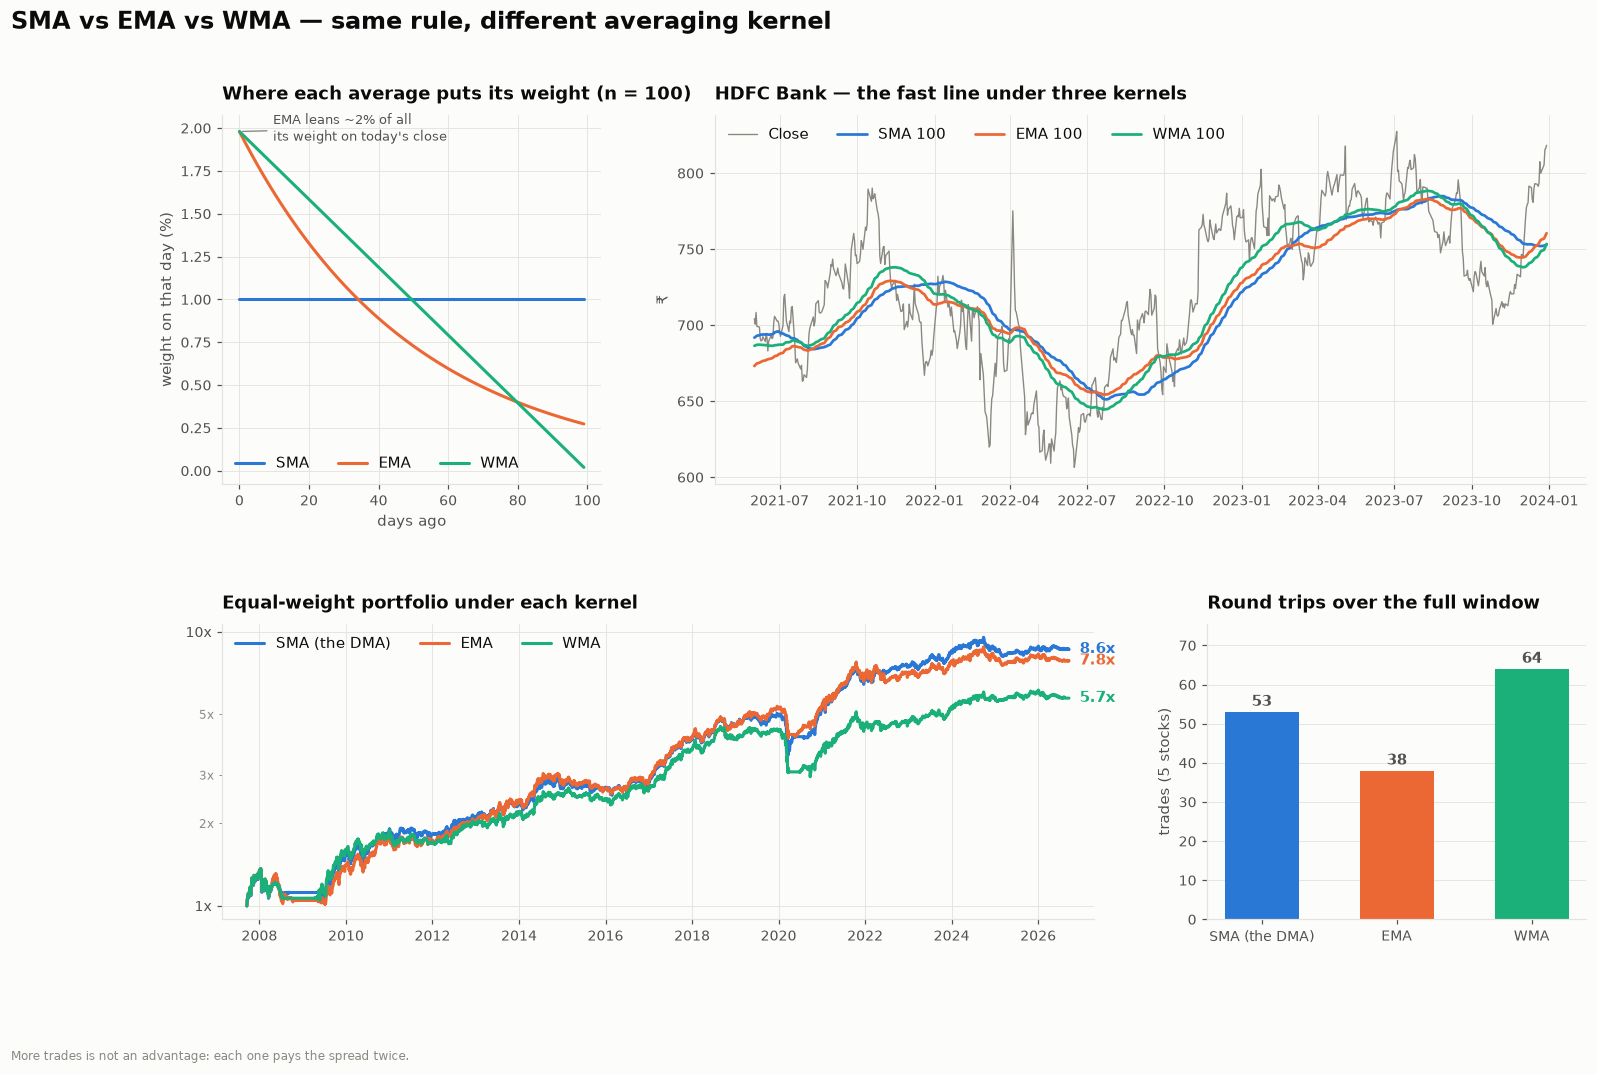

In [14]:
fig = plt.figure(figsize=(16, 9.5))
gs  = fig.add_gridspec(2, 3, height_ratios=[1.25, 1], hspace=0.42, wspace=0.3)

# -- what the three kernels actually weight ----------------------------------
ax = fig.add_subplot(gs[0, 0])
n = 100
lags = np.arange(n)
w_sma = np.full(n, 1 / n)
w_ema = (2 / (n + 1)) * (1 - 2 / (n + 1)) ** lags
w_wma = (n - lags) / (n * (n + 1) / 2)
for w, lbl, colr in [(w_sma, "SMA", C["s1_blue"]), (w_ema, "EMA", C["s2_orange"]),
                     (w_wma, "WMA", C["s3_aqua"])]:
    ax.plot(lags, w * 100, color=colr, label=lbl)
ax.set_xlabel("days ago"); ax.set_ylabel("weight on that day (%)")
ax.set_title("Where each average puts its weight (n = 100)", loc="left")
ax.legend(ncols=3)
ax.annotate("EMA leans ~2% of all\nits weight on today's close",
            (0, w_ema[0] * 100), xytext=(22, -6), textcoords="offset points",
            fontsize=8.5, color=C["ink_2"],
            arrowprops=dict(arrowstyle="-", color=C["ink_muted"], lw=0.9))

# -- the three lines on one stock --------------------------------------------
ax = fig.add_subplot(gs[0, 1:])
demo = "HDFCBANK.NS"
dd = frame(demo).loc["2021-06-01":"2023-12-31"]
ax.plot(dd.index, dd["Close"], color=C["ink_muted"], lw=0.9, label="Close")
for kind, lbl, colr in [("sma", "SMA 100", C["s1_blue"]), ("ema", "EMA 100", C["s2_orange"]),
                        ("wma", "WMA 100", C["s3_aqua"])]:
    m = moving_average(frame(demo)["Close"], FAST, kind).loc[dd.index]
    ax.plot(m.index, m, color=colr, lw=1.8, label=lbl)
ax.set_title(f"{STOCKS[demo]} — the fast line under three kernels", loc="left")
ax.set_ylabel("₹"); ax.legend(ncols=4)

# -- equity curves -----------------------------------------------------------
ax = fig.add_subplot(gs[1, :2])
pairs = []
for (lbl, eqc), colr in zip(curves.items(), [C["s1_blue"], C["s2_orange"], C["s3_aqua"]]):
    ax.plot(eqc.index, eqc, color=colr, label=lbl); pairs.append((eqc, colr))
end_labels(ax, pairs)
log_money(ax)
ax.set_title("Equal-weight portfolio under each kernel", loc="left")
ax.legend(ncols=3, loc="upper left"); ax.margins(x=0.03)

# -- the trade-count tax -----------------------------------------------------
ax = fig.add_subplot(gs[1, 2])
ax.bar(MAC.index, MAC["Round trips"], color=[C["s1_blue"], C["s2_orange"], C["s3_aqua"]],
       width=0.55)
for i, v in enumerate(MAC["Round trips"]):
    ax.annotate(f"{v:,.0f}", (i, v), xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=10, weight="bold", color=C["ink_2"])
ax.set_title("Round trips over the full window", loc="left")
ax.set_ylabel("trades (5 stocks)"); ax.grid(axis="x", visible=False); ax.margins(y=0.18)

fig.suptitle("SMA vs EMA vs WMA — same rule, different averaging kernel",
             x=0.005, ha="left", fontsize=16, weight="bold")
finish(fig, "More trades is not an advantage: each one pays the spread twice.")
fig.savefig(CHARTS / "10_sma_vs_ema.png")
plt.show()

**Read the table, not the story — including where it contradicts the story.**

On this sample the SMA wins CAGR and Sharpe, the EMA wins max drawdown and Calmar, and the WMA
loses on everything. The interesting result is the trade count: the **EMA traded materially
less than the SMA**, not more. That is the drop-out effect (reason 5) showing up in the P&L —
a simple average produces crossings caused by a price *leaving* the back of the window, and each
one is a round trip you paid for and did not need. Textbook intuition says the EMA is the
twitchy one; on 19 years of these five stocks it was the calmer one.

None of these gaps is significant on ~50 round trips per kernel. That is exactly why the choice
here rests on reasons 3 and 4 — the crowd effect and the smaller fitting surface — rather than
on whichever line won the backtest. If you prefer the EMA's shallower drawdown, set
`kind="ema"` in `signal_and_position` and re-run the whole notebook; nothing else changes.

## 7 · The equal-weight portfolio

Five sleeves, 20% of capital each, rebalanced daily (each sleeve keeps its own signal; capital
in a flat sleeve earns `CASH_YIELD`). Compared against an equal-weight buy & hold of the same
five names and against the Nifty 50.

,Total return,CAGR,Ann. vol,Sharpe,Sortino,Max DD,Calmar,Longest DD (d),Best month,Worst month,% up months,Time in mkt
100/200 DMA portfolio,764%,12.28%,14.16%,0.47,0.61,-29.5%,0.42,525,16.5%,-17.9%,59%,67%
Buy & hold portfolio,"1,297%",15.22%,21.80%,0.48,0.66,-57.2%,0.27,493,26.2%,-26.9%,61%,100%
NIFTY 50,419%,9.25%,20.46%,0.24,0.31,-59.9%,0.15,735,28.1%,-26.4%,56%,100%


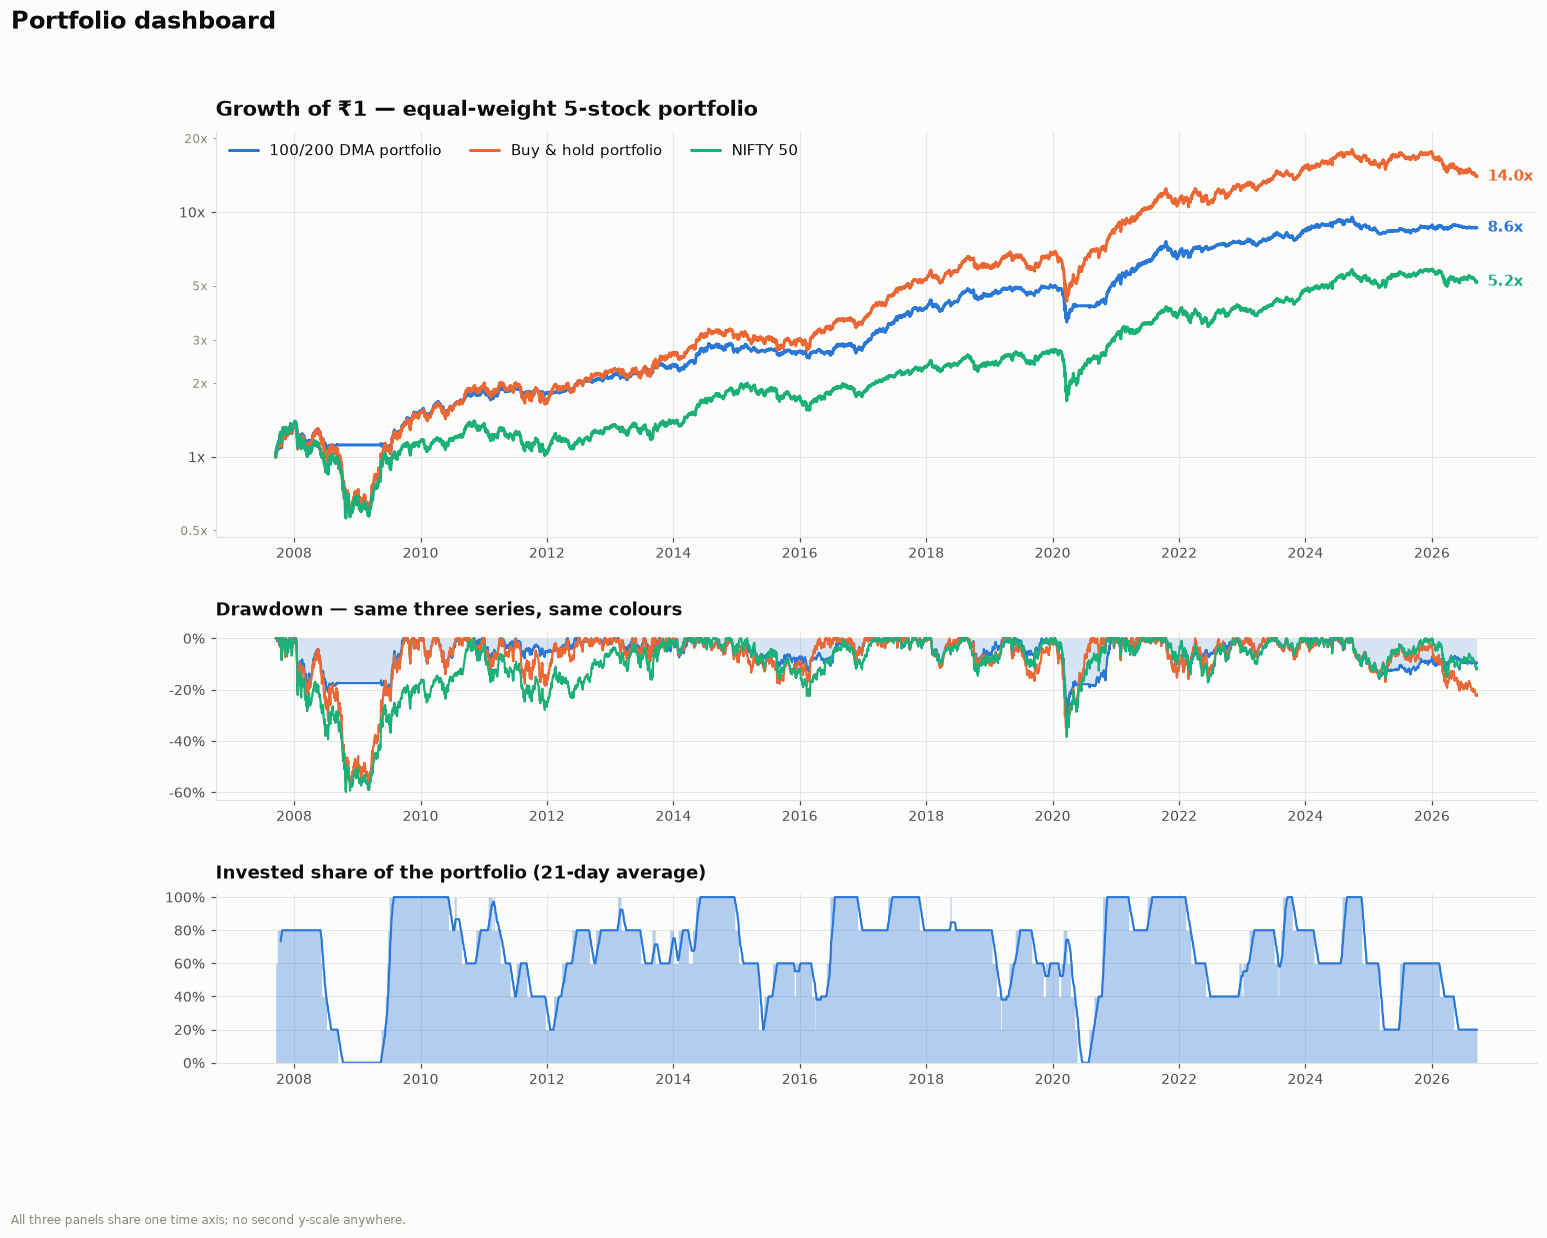

In [15]:
RS = pd.DataFrame({t: RES[t]["r_s"] for t in STOCKS}).dropna(how="all").fillna(0.0)
RB = pd.DataFrame({t: RES[t]["r_b"] for t in STOCKS}).dropna(how="all").fillna(0.0)
port_s, port_b = RS.mean(axis=1), RB.mean(axis=1)
EQ = pd.DataFrame({"100/200 DMA portfolio": equity(port_s),
                   "Buy & hold portfolio":  equity(port_b),
                   "NIFTY 50":              equity(r_n.reindex(port_s.index).fillna(0.0))})
expo = pd.DataFrame({t: RES[t]["pos"].loc[BACKTEST_START:].fillna(0) for t in STOCKS}
                    ).reindex(port_s.index).fillna(0).mean(axis=1)

PSTAT = pd.DataFrame({
    "100/200 DMA portfolio": perf_stats(port_s, exposure=expo.mean()),
    "Buy & hold portfolio":  perf_stats(port_b, exposure=1.0),
    "NIFTY 50":              perf_stats(r_n.reindex(port_s.index).fillna(0.0)),
}).T
display(PSTAT.style.format({**fmt, "Best month": "{:.1%}", "Worst month": "{:.1%}",
                            "Longest DD (d)": "{:,.0f}"})
        .set_caption("Portfolio level - 20% per sleeve, rebalanced daily"))

fig = plt.figure(figsize=(15.5, 11))
gs  = fig.add_gridspec(3, 1, height_ratios=[2.4, 1.0, 1.0], hspace=0.38)

ax = fig.add_subplot(gs[0])
for col, colr in zip(EQ.columns, [C["s1_blue"], C["s2_orange"], C["s3_aqua"]]):
    ax.plot(EQ.index, EQ[col], color=colr, label=col)
    ax.annotate(f"{EQ[col].iloc[-1]:,.1f}x", (EQ.index[-1], EQ[col].iloc[-1]), xytext=(7, 0),
                textcoords="offset points", color=colr, weight="bold", fontsize=10, va="center")
log_money(ax)
ax.set_title("Growth of ₹1 — equal-weight 5-stock portfolio", loc="left", fontsize=14)
ax.legend(ncols=3, loc="upper left"); ax.margins(x=0.03)

ax2 = fig.add_subplot(gs[1], sharex=ax)
for col, colr in zip(EQ.columns, [C["s1_blue"], C["s2_orange"], C["s3_aqua"]]):
    dd = drawdown(EQ[col])
    ax2.plot(dd.index, dd, color=colr, lw=1.4, label=col)
ax2.fill_between(EQ.index, drawdown(EQ.iloc[:, 0]), 0, color=C["s1_blue"], alpha=0.18, lw=0)
ax2.yaxis.set_major_formatter(FuncFormatter(pct))
ax2.set_title("Drawdown — same three series, same colours", loc="left", fontsize=12)

ax3 = fig.add_subplot(gs[2], sharex=ax)
ax3.fill_between(expo.index, expo, 0, color=C["s1_blue"], alpha=0.35, lw=0, step="post")
ax3.plot(expo.index, expo.rolling(21).mean(), color=C["s1_blue"], lw=1.4,
         label="share of sleeves long (21d avg)")
ax3.set_ylim(0, 1.02); ax3.yaxis.set_major_formatter(FuncFormatter(pct))
ax3.set_title("Invested share of the portfolio (21-day average)", loc="left", fontsize=12)
fig.suptitle("Portfolio dashboard", x=0.005, ha="left", fontsize=16, weight="bold")
finish(fig, "All three panels share one time axis; no second y-scale anywhere.")
fig.savefig(CHARTS / "06_portfolio.png")
plt.show()

### 7.1 · Calendar-year returns and the monthly grid

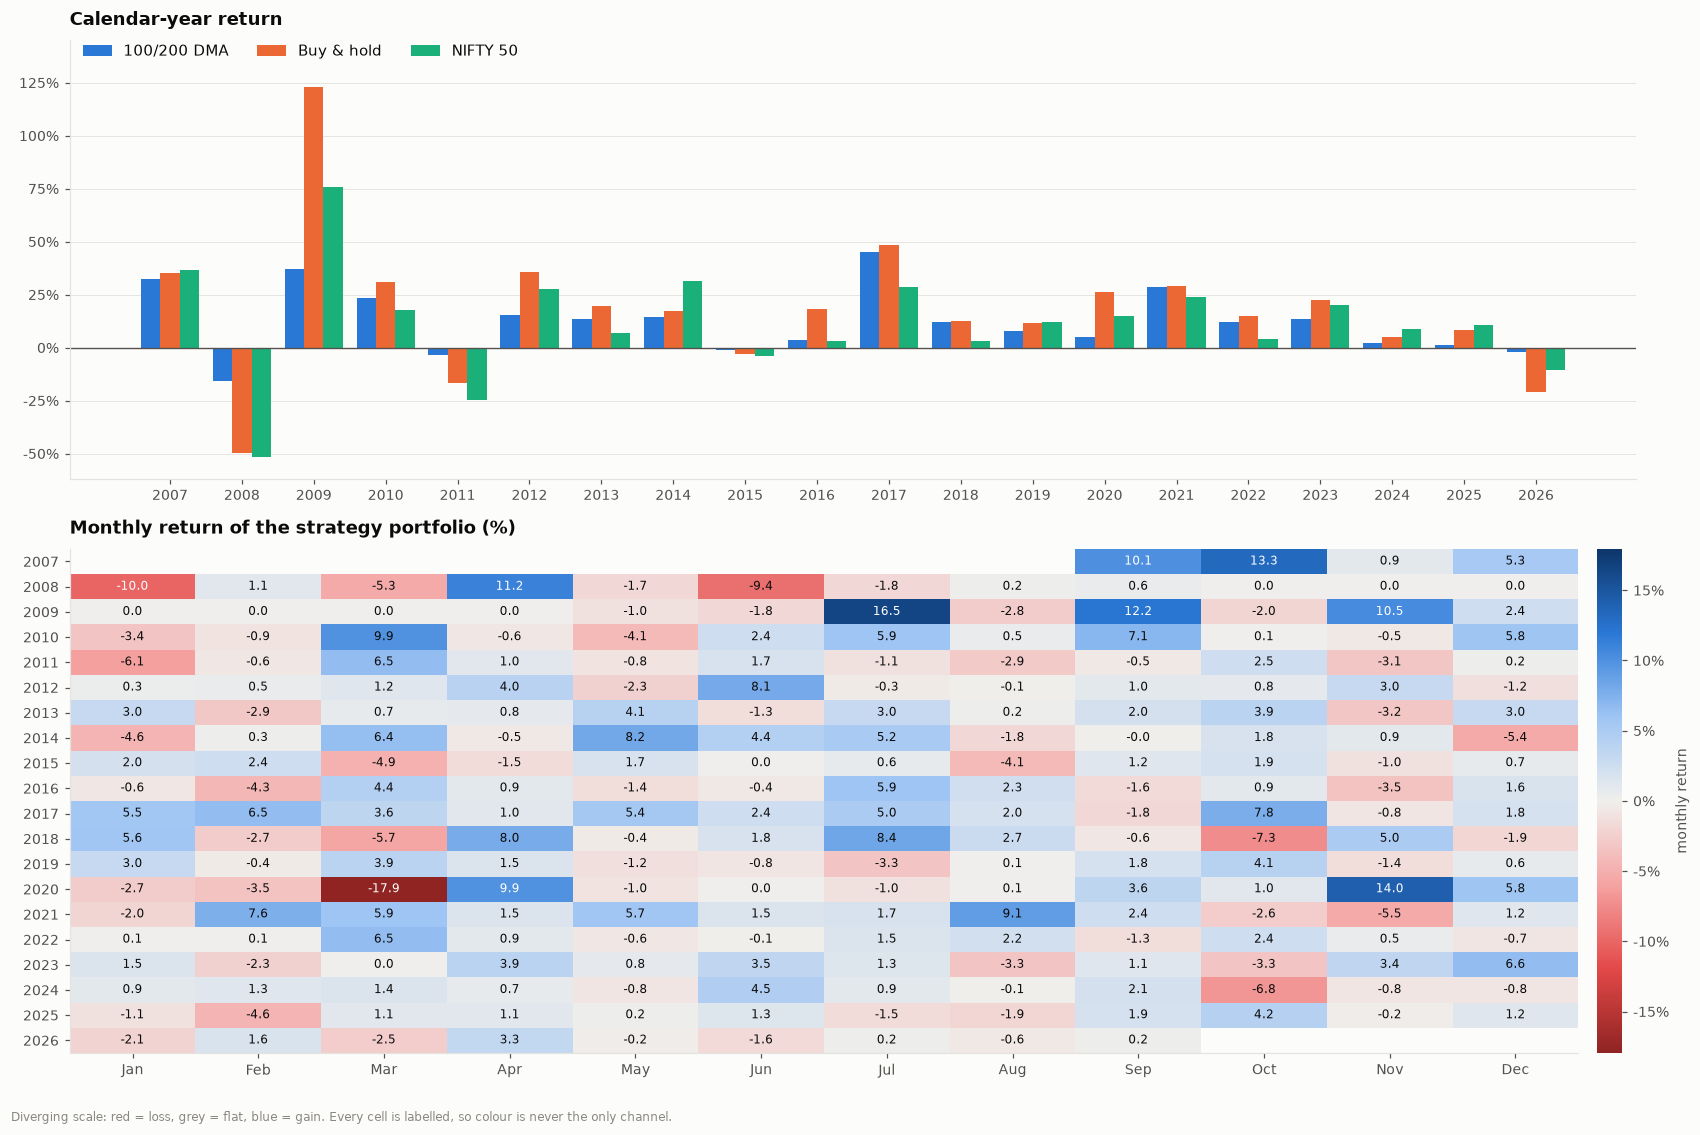

In [16]:
yr = pd.DataFrame({
    "100/200 DMA": (1 + port_s).resample("YE").prod() - 1,
    "Buy & hold":  (1 + port_b).resample("YE").prod() - 1,
    "NIFTY 50":    (1 + r_n.reindex(port_s.index).fillna(0)).resample("YE").prod() - 1,
})
yr.index = yr.index.year

fig, (axA, axB) = plt.subplots(2, 1, figsize=(15.5, 10), height_ratios=[1, 1.15])
x, w = np.arange(len(yr)), 0.27
for i, (col, colr) in enumerate(zip(yr.columns, [C["s1_blue"], C["s2_orange"], C["s3_aqua"]])):
    axA.bar(x + (i - 1) * w, yr[col], width=w, color=colr, label=col)
axA.axhline(0, color=C["ink_2"], lw=0.9)
axA.set_xticks(x, yr.index); axA.yaxis.set_major_formatter(FuncFormatter(pct))
axA.grid(axis="x", visible=False)
lo, hi = float(yr.to_numpy().min()), float(yr.to_numpy().max())
axA.set_ylim(lo - 0.10, hi + 0.22)
axA.set_title("Calendar-year return", loc="left")
axA.legend(ncols=3, loc="upper left", bbox_to_anchor=(0, 1.02))

m  = (1 + port_s).resample("ME").prod() - 1
hm = m.to_frame("r").assign(y=m.index.year, mo=m.index.month).pivot(index="y", columns="mo", values="r")
hm = hm.reindex(columns=range(1, 13))
lim = float(np.nanmax(np.abs(hm.to_numpy())))
im = axB.imshow(hm.to_numpy(), cmap=DIVERGING, norm=TwoSlopeNorm(0, -lim, lim), aspect="auto")
axB.set_xticks(range(12), ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
axB.set_yticks(range(len(hm)), hm.index)
axB.grid(visible=False)
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        v = hm.to_numpy()[i, j]
        if not np.isnan(v):
            axB.text(j, i, f"{v*100:.1f}", ha="center", va="center", fontsize=7.6,
                     color="#ffffff" if abs(v) > lim * 0.55 else C["ink"])
axB.set_title("Monthly return of the strategy portfolio (%)", loc="left")
cb = fig.colorbar(im, ax=axB, pad=0.012, fraction=0.025)
cb.ax.yaxis.set_major_formatter(FuncFormatter(pct)); cb.outline.set_visible(False)
cb.set_label("monthly return", color=C["ink_2"], fontsize=9)
finish(fig, "Diverging scale: red = loss, grey = flat, blue = gain. Every cell is labelled, so colour is never the only channel.")
fig.savefig(CHARTS / "07_calendar.png")
plt.show()

### 7.2 · What the trades actually looked like

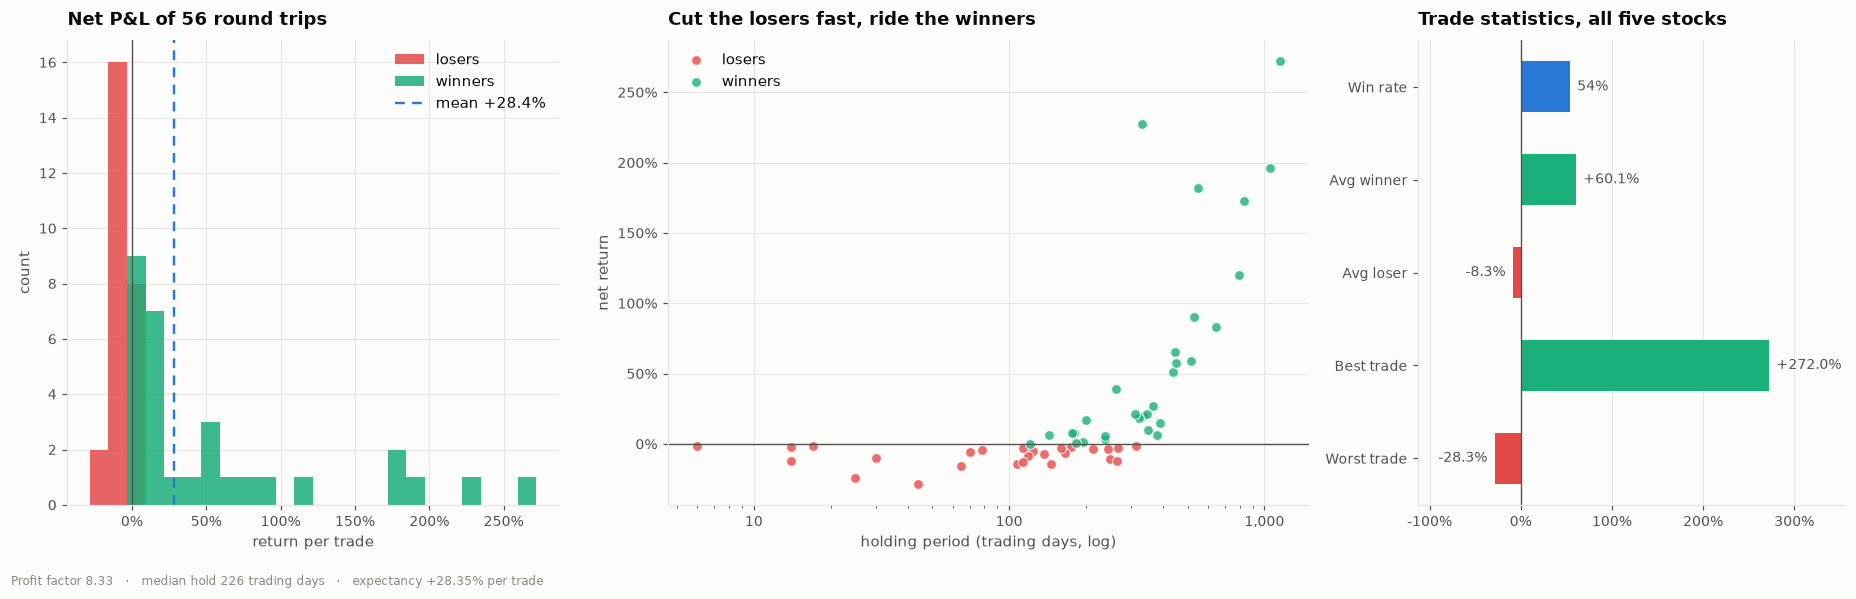

stock,entry,exit,bars,entry_px,exit_px,net
ITC,2009-05-18 00:00:00,2014-01-02 00:00:00,1148,36.280000,135.250000,+272.0%
Tata Steel,2020-10-13 00:00:00,2022-02-08 00:00:00,330,31.380000,103.050000,+227.8%
Reliance Industries,2015-07-28 00:00:00,2019-11-08 00:00:00,1053,217.480000,645.230000,+196.1%
Tata Consultancy Services,2009-06-25 00:00:00,2011-09-07 00:00:00,549,130.090000,367.770000,+182.1%
ITC,2020-10-13 00:00:00,2024-02-19 00:00:00,831,129.100000,352.940000,+172.8%
Tata Consultancy Services,2012-02-09 00:00:00,2015-05-05 00:00:00,792,433.120000,955.260000,+120.1%
Tata Steel,2016-04-01 00:00:00,2018-05-25 00:00:00,532,22.890000,43.610000,+90.1%
HDFC Bank,2016-06-03 00:00:00,2019-01-16 00:00:00,649,266.880000,489.710000,+83.1%
Tata Consultancy Services,2017-05-23 00:00:00,2019-03-08 00:00:00,446,1001.450000,1655.730000,+65.0%
HDFC Bank,2014-01-29 00:00:00,2016-03-09 00:00:00,517,144.120000,229.090000,+58.6%


In [17]:
ALL = pd.concat([RES[t]["trades"].assign(stock=RES[t]["name"]) for t in STOCKS], ignore_index=True)
ALL["year"] = pd.to_datetime(ALL["entry"]).dt.year
win = ALL["net"] > 0

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2), width_ratios=[1.15, 1.5, 1])

ax = axes[0]
bins = np.histogram_bin_edges(ALL["net"], bins=24)
ax.hist(ALL.loc[~win, "net"], bins=bins, color=C["bad"],  alpha=0.85, label="losers")
ax.hist(ALL.loc[win,  "net"], bins=bins, color=C["good"], alpha=0.85, label="winners")
ax.axvline(0, color=C["ink_2"], lw=0.9)
ax.axvline(ALL["net"].mean(), color=C["s1_blue"], lw=1.6, ls=(0, (4, 3)),
           label=f"mean {ALL['net'].mean():+.1%}")
ax.xaxis.set_major_formatter(FuncFormatter(pct))
ax.set_title(f"Net P&L of {len(ALL)} round trips", loc="left")
ax.set_xlabel("return per trade"); ax.set_ylabel("count"); ax.legend()

ax = axes[1]
ax.axhline(0, color=C["ink_2"], lw=0.9)
ax.scatter(ALL.loc[~win, "bars"], ALL.loc[~win, "net"], s=42, color=C["bad"],
           alpha=0.8, edgecolor=C["surface"], lw=0.8, label="losers")
ax.scatter(ALL.loc[win, "bars"], ALL.loc[win, "net"], s=42, color=C["good"],
           alpha=0.8, edgecolor=C["surface"], lw=0.8, label="winners")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.yaxis.set_major_formatter(FuncFormatter(pct))
ax.set_xlabel("holding period (trading days, log)"); ax.set_ylabel("net return")
ax.set_title("Cut the losers fast, ride the winners", loc="left"); ax.legend()

ax = axes[2]
summary = pd.Series({
    "Win rate":        win.mean(),
    "Avg winner":      ALL.loc[win, "net"].mean(),
    "Avg loser":       ALL.loc[~win, "net"].mean(),
    "Best trade":      ALL["net"].max(),
    "Worst trade":     ALL["net"].min(),
})
lab = list(summary.index)
vals = summary.to_numpy()
cols = [C["s1_blue"]] + [C["good"] if v > 0 else C["bad"] for v in vals[1:]]
ax.barh(np.arange(len(lab)), vals, color=cols, height=0.55)
ax.set_yticks(np.arange(len(lab)), lab); ax.invert_yaxis()
ax.axvline(0, color=C["ink_2"], lw=0.9)
ax.xaxis.set_major_formatter(FuncFormatter(pct))
ax.grid(axis="y", visible=False)
for i, v in enumerate(vals):
    ax.annotate(f"{v:+.1%}" if i else f"{v:.0%}", (v, i),
                xytext=(5 if v >= 0 else -5, 0), textcoords="offset points",
                ha="left" if v >= 0 else "right", va="center", fontsize=9, color=C["ink_2"])
ax.margins(x=0.28)
ax.set_title("Trade statistics, all five stocks", loc="left")
pf = ALL.loc[win, "net"].sum() / abs(ALL.loc[~win, "net"].sum())
finish(fig, f"Profit factor {pf:.2f}   ·   median hold {ALL['bars'].median():.0f} trading days   ·   "
            f"expectancy {ALL['net'].mean():+.2%} per trade")
fig.savefig(CHARTS / "08_trades.png")
plt.show()
display(ALL.sort_values("net", ascending=False)
        .head(10)[["stock", "entry", "exit", "bars", "entry_px", "exit_px", "net"]]
        .style.hide(axis="index").format({"net": "{:+.1%}"})
        .set_caption("Ten biggest winners"))

## 8 · Buy & hold vs the NIFTY 50

Section 5 asked *"does the crossover rule beat owning the stock?"*. This one asks the prior
question — **does owning the stock beat owning the index?** If the answer is no, the whole
single-stock exercise was a detour and you should have bought an index fund.

The benchmark is the Nifty 50 price index (`^NSEI`). One caveat to keep in mind while reading
every number below: `^NSEI` is a **price** index, it excludes dividends, whereas the stock
series are total-return (`auto_adjust=True`). Nifty's dividend yield has run ~1.2–1.5%, so the
index's true total return is roughly that much higher than shown, and every "excess return"
here is flattered by about the same amount.

In [18]:
IDX  = RB.index
rn   = r_n.reindex(IDX).fillna(0.0)
BH   = {RES[t]["name"]: RB[t] for t in STOCKS}
BH["Equal-weight 5"] = port_b

def vs_benchmark(r, rb, rf=RF_ANNUAL, periods=252):
    '''CAPM-style comparison of one return stream against the benchmark.'''
    r, rb = r.align(rb, join="inner")
    ex_r, ex_b = r - rf / periods, rb - rf / periods
    var_b = float(np.var(ex_b, ddof=1))
    beta  = float(np.cov(ex_r, ex_b, ddof=1)[0, 1] / var_b)
    alpha = float(ex_r.mean() - beta * ex_b.mean()) * periods
    active = r - rb
    te  = float(active.std() * np.sqrt(periods))
    yrs = len(r) / periods
    cagr   = float((1 + r).prod()  ** (1 / yrs) - 1)
    cagr_b = float((1 + rb).prod() ** (1 / yrs) - 1)

    m_r = (1 + r).resample("ME").prod()  - 1
    m_b = (1 + rb).resample("ME").prod() - 1
    up, dn = m_b > 0, m_b < 0
    geo = lambda x: (1 + x).prod() ** (1 / len(x)) - 1 if len(x) else np.nan

    y_r = (1 + r).resample("YE").prod()  - 1
    y_b = (1 + rb).resample("YE").prod() - 1
    return {
        "CAGR":          cagr,
        "Excess CAGR":   cagr - cagr_b,
        "Beta":          beta,
        "Alpha (ann.)":  alpha,
        "R²":            float(r.corr(rb) ** 2),
        "Tracking err":  te,
        "Info ratio":    float(active.mean() * periods / te),
        "Up capture":    float(geo(m_r[up]) / geo(m_b[up])),
        "Down capture":  float(geo(m_r[dn]) / geo(m_b[dn])),
        "Years beaten":  f"{int((y_r > y_b).sum())}/{len(y_b)}",
    }

BENCH = pd.DataFrame({k: vs_benchmark(v, rn) for k, v in BH.items()}).T
BENCH.loc["NIFTY 50 (self)"] = vs_benchmark(rn, rn)
BENCH.loc["NIFTY 50 (self)", ["Info ratio", "Years beaten"]] = [np.nan, "—"]

fmt_b = {"CAGR": "{:.2%}", "Excess CAGR": "{:+.2%}", "Beta": "{:.2f}", "Alpha (ann.)": "{:+.2%}",
         "R²": "{:.2f}", "Tracking err": "{:.1%}", "Info ratio": "{:+.2f}",
         "Up capture": "{:.0%}", "Down capture": "{:.0%}"}
display(BENCH.style.format(fmt_b, na_rep="—").set_caption(
    f"Buy & hold vs NIFTY 50 — {IDX[0].date()} to {IDX[-1].date()}.  "
    "Up/down capture: share of the index's average up (down) month you captured; "
    "for down capture, lower is better."))

,CAGR,Excess CAGR,Beta,Alpha (ann.),R²,Tracking err,Info ratio,Up capture,Down capture,Years beaten
Reliance Industries,10.14%,+0.89%,1.14,+2.92%,0.55,21.1%,+0.17,98%,94%,11/20
Tata Consultancy Services,14.51%,+5.26%,0.75,+8.05%,0.28,25.2%,+0.27,73%,42%,11/20
HDFC Bank,15.25%,+5.99%,0.98,+7.06%,0.54,18.5%,+0.38,109%,88%,13/20
ITC,11.74%,+2.48%,0.65,+5.36%,0.25,23.8%,+0.15,70%,49%,9/20
Tata Steel,9.86%,+0.60%,1.34,+5.28%,0.44,31.6%,+0.22,146%,158%,11/20
Equal-weight 5,15.22%,+5.97%,0.97,+5.73%,0.83,8.9%,+0.63,104%,81%,14/20
NIFTY 50 (self),9.25%,+0.00%,1.00,-0.00%,1.00,0.0%,—,100%,100%,—


### 8.1 · The index is the line to beat

Left: ₹1 in each stock against ₹1 in the index. Right: the same thing expressed as a ratio —
**the stock divided by the index**, rebased to 1. A rising line means the stock is beating the
index *at that moment*; the level tells you the cumulative score. This second panel is the one
that matters, because a line can end high and still have spent a decade going sideways against
the benchmark.

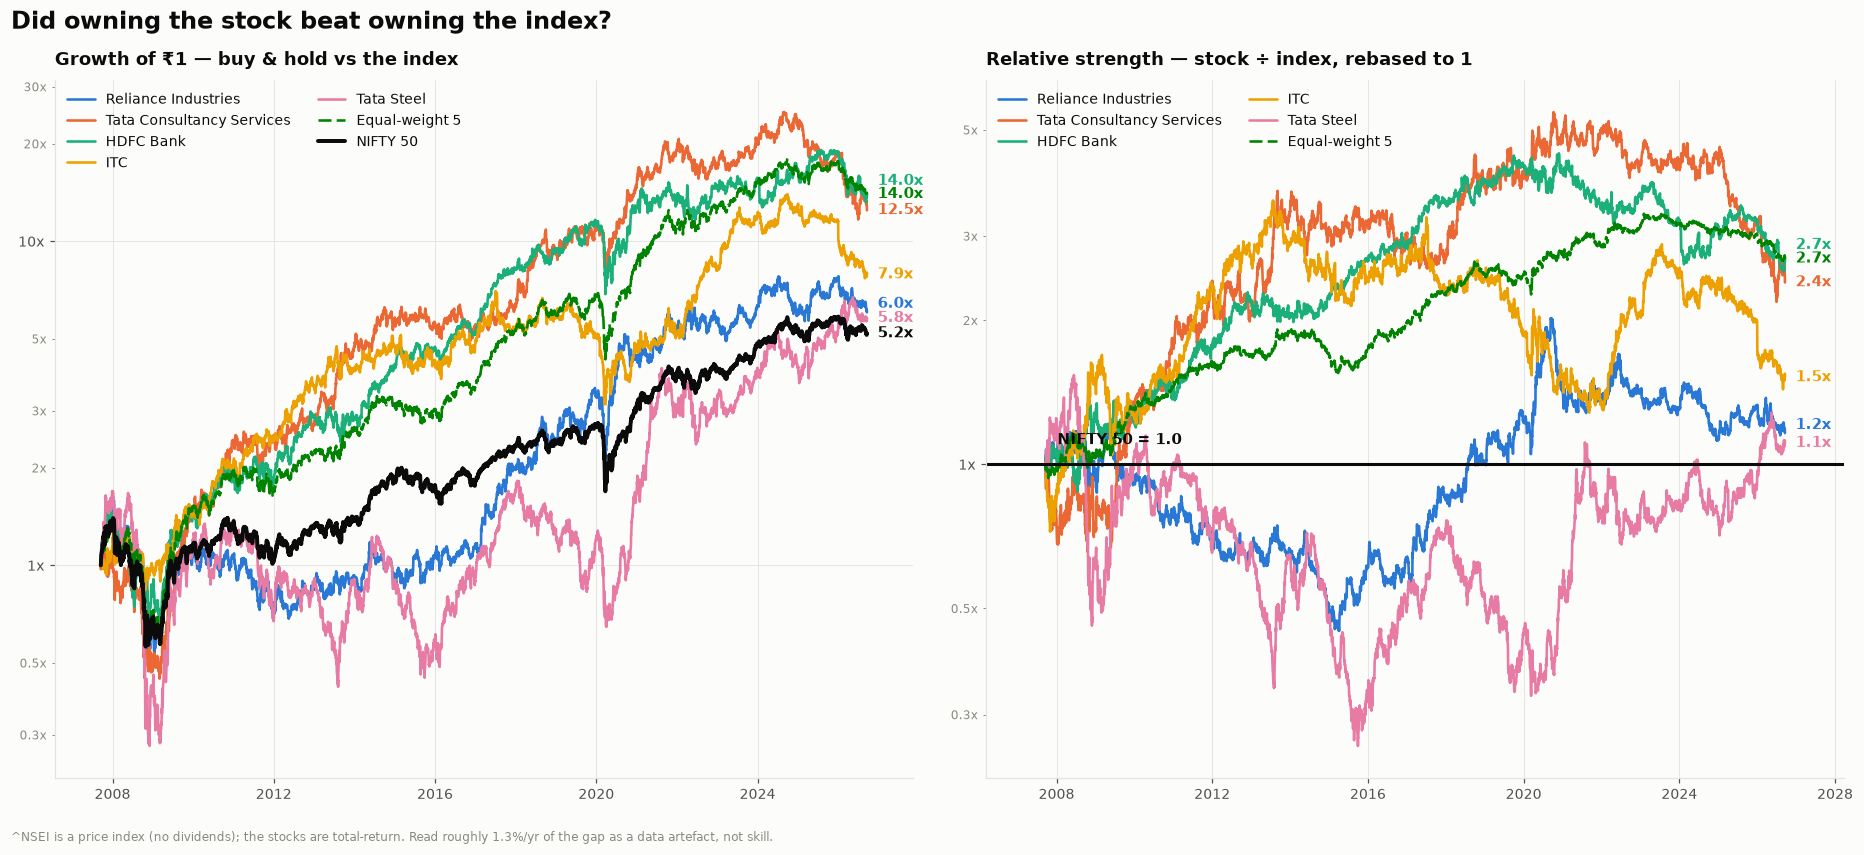

In [19]:
SER_COLORS = [C["s1_blue"], C["s2_orange"], C["s3_aqua"], C["s4_yellow"], C["s5_magenta"]]
eq_n_al = equity(rn)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(17, 7.5))

pairs = []
for (t, colr) in zip(STOCKS, SER_COLORS):
    e = equity(RB[t]); pairs.append((e, colr))
    axA.plot(e.index, e, color=colr, lw=1.7, label=RES[t]["name"])
e_p = equity(port_b)
axA.plot(e_p.index, e_p, color=C["s6_green"], lw=1.7, ls=(0, (5, 2)), label="Equal-weight 5")
axA.plot(eq_n_al.index, eq_n_al, color=C["ink"], lw=2.6, label="NIFTY 50")
pairs += [(e_p, C["s6_green"]), (eq_n_al, C["ink"])]
end_labels(axA, pairs)
log_money(axA)
axA.set_title("Growth of ₹1 — buy & hold vs the index", loc="left")
axA.legend(ncols=2, loc="upper left", fontsize=9); axA.margins(x=0.06)

rs_pairs = []
for (t, colr) in zip(STOCKS, SER_COLORS):
    rel = equity(RB[t]) / eq_n_al
    axB.plot(rel.index, rel, color=colr, lw=1.7, label=RES[t]["name"])
    rs_pairs.append((rel, colr))
rel_p = e_p / eq_n_al
axB.plot(rel_p.index, rel_p, color=C["s6_green"], lw=1.7, ls=(0, (5, 2)), label="Equal-weight 5")
rs_pairs.append((rel_p, C["s6_green"]))
axB.axhline(1.0, color=C["ink"], lw=2.0)
axB.annotate("NIFTY 50 = 1.0", (rel.index[0], 1.0), xytext=(8, 11),
             textcoords="offset points", color=C["ink"], fontsize=9.5, weight="bold",
             va="bottom")
end_labels(axB, rs_pairs)
log_money(axB)
axB.set_title("Relative strength — stock ÷ index, rebased to 1", loc="left")
axB.legend(ncols=2, loc="upper left", fontsize=9); axB.margins(x=0.08)

fig.suptitle("Did owning the stock beat owning the index?", x=0.005, ha="left",
             fontsize=16, weight="bold")
finish(fig, "^NSEI is a price index (no dividends); the stocks are total-return. "
            "Read roughly 1.3%/yr of the gap as a data artefact, not skill.")
fig.savefig(CHARTS / "11_bh_vs_nifty.png")
plt.show()

### 8.2 · Alpha, beta and capture

**Beta** is how much index risk you were taking. **Alpha** is what is left after paying for that
beta at the index's own rate — the only part that is arguably skill rather than exposure.
**Capture** splits the record in two: what share of the index's average *up* month you got, and
what share of its average *down* month you ate. A stock that beats the index by taking 1.3× the
risk has not beaten anything; look for high up-capture with low down-capture.

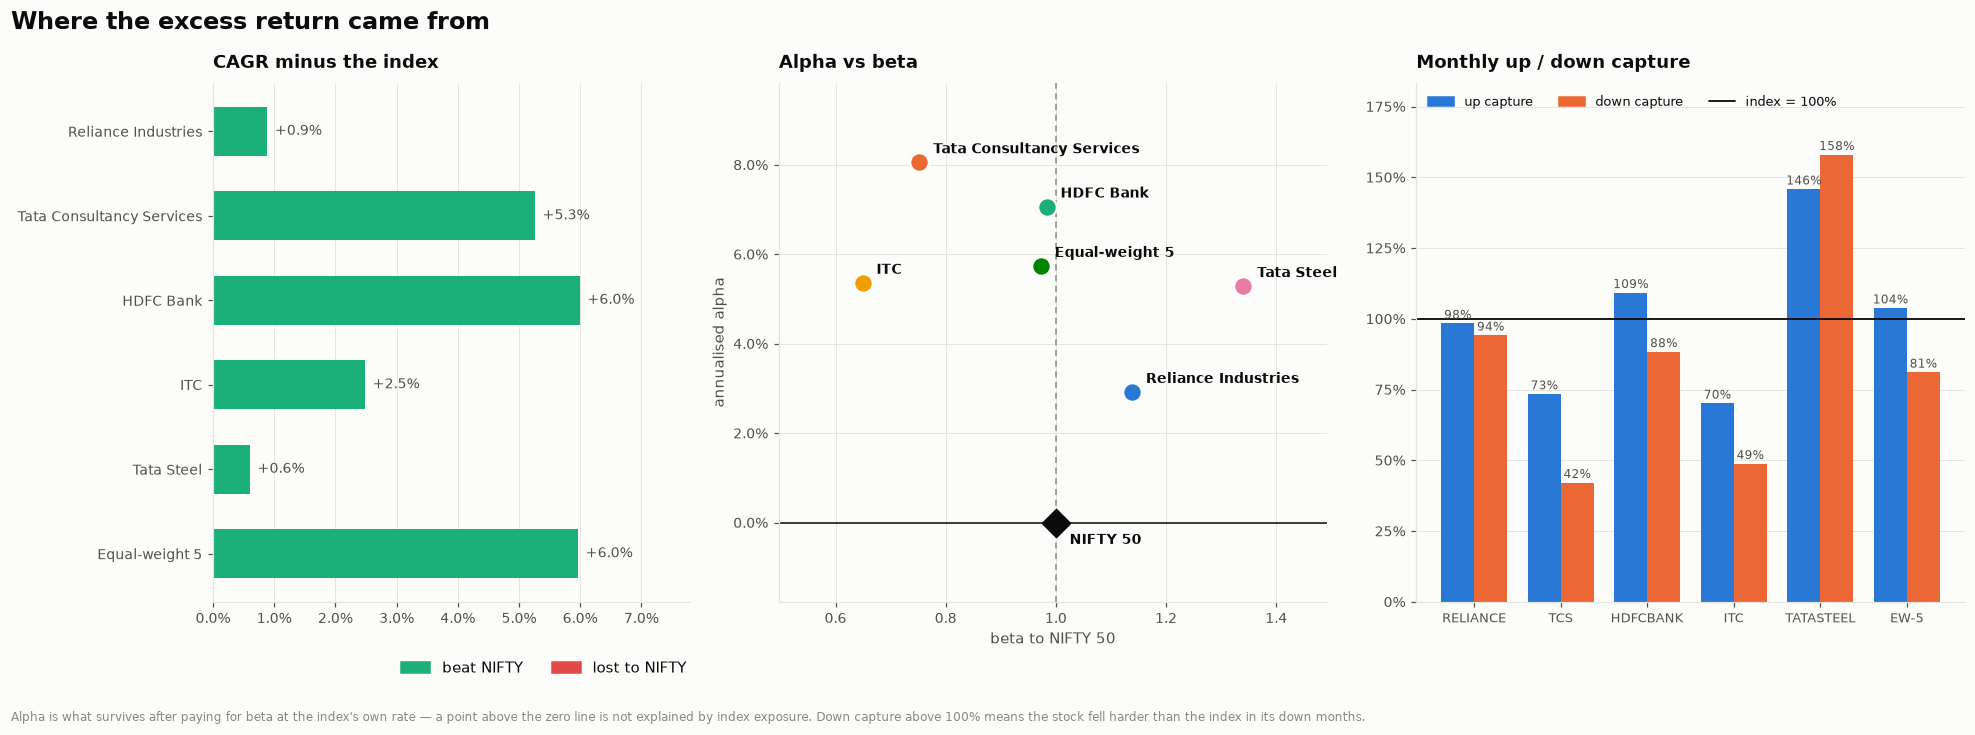

In [20]:
names  = list(BH)
SHORT  = [t.replace(".NS", "").replace(".BO", "") for t in STOCKS] + ["EW-5"]
fig, axes = plt.subplots(1, 3, figsize=(18, 6.4), width_ratios=[1, 1.15, 1.15])

# -- excess CAGR --------------------------------------------------------------
ax = axes[0]
ex = BENCH.loc[names, "Excess CAGR"].astype(float)
cols = [C["good"] if v > 0 else C["bad"] for v in ex]
ax.barh(np.arange(len(ex)), ex, color=cols, height=0.58)
ax.set_yticks(np.arange(len(ex)), names); ax.invert_yaxis()
ax.axvline(0, color=C["ink"], lw=1.2)
ax.xaxis.set_major_formatter(FuncFormatter(pct1)); ax.grid(axis="y", visible=False)
for i, v in enumerate(ex):
    ax.annotate(f"{v:+.1%}", (v, i), xytext=(5 if v >= 0 else -5, 0),
                textcoords="offset points", va="center", fontsize=9,
                ha="left" if v >= 0 else "right", color=C["ink_2"])
ax.margins(x=0.30)
ax.set_title("CAGR minus the index", loc="left")
ax.legend(handles=[Patch(color=C["good"], label="beat NIFTY"),
                   Patch(color=C["bad"],  label="lost to NIFTY")],
          ncols=2, loc="upper right", bbox_to_anchor=(1.02, -0.09))

# -- alpha vs beta ------------------------------------------------------------
ax = axes[1]
bet = BENCH.loc[names, "Beta"].astype(float)
alp = BENCH.loc[names, "Alpha (ann.)"].astype(float)
ax.axhline(0, color=C["ink"], lw=1.0)
ax.axvline(1, color=C["ink_muted"], lw=1.0, ls=(0, (4, 3)))
for nm, b, a, colr in zip(names, bet, alp, SER_COLORS + [C["s6_green"]]):
    ax.scatter([b], [a], s=150, color=colr, edgecolor=C["surface"], lw=1.5, zorder=4)
    ax.annotate(nm, (b, a), xytext=(9, 6), textcoords="offset points", fontsize=9,
                color=C["ink"], weight="bold")
ax.scatter([1], [0], s=170, marker="D", color=C["ink"], zorder=5)
ax.annotate("NIFTY 50", (1, 0), xytext=(9, -14), textcoords="offset points",
            fontsize=9, color=C["ink"], weight="bold")
ax.yaxis.set_major_formatter(FuncFormatter(pct1))
ax.set_xlabel("beta to NIFTY 50"); ax.set_ylabel("annualised alpha")
ax.set_title("Alpha vs beta", loc="left")
ax.margins(0.22)

# -- up / down capture --------------------------------------------------------
ax = axes[2]
x, w = np.arange(len(names)), 0.38
upc = BENCH.loc[names, "Up capture"].astype(float)
dnc = BENCH.loc[names, "Down capture"].astype(float)
ax.bar(x - w/2, upc, width=w, color=C["s1_blue"],   label="up capture")
ax.bar(x + w/2, dnc, width=w, color=C["s2_orange"], label="down capture")
ax.axhline(1.0, color=C["ink"], lw=1.2)
ax.set_xticks(x, SHORT, fontsize=8.5)
ax.yaxis.set_major_formatter(FuncFormatter(pct)); ax.grid(axis="x", visible=False)
for xi, (u, d) in enumerate(zip(upc, dnc)):
    ax.annotate(f"{u:.0%}", (xi - w/2, u), xytext=(0, 3), textcoords="offset points",
                ha="center", fontsize=8, color=C["ink_2"])
    ax.annotate(f"{d:.0%}", (xi + w/2, d), xytext=(0, 3), textcoords="offset points",
                ha="center", fontsize=8, color=C["ink_2"])
ax.set_title("Monthly up / down capture", loc="left")
ax.legend(handles=[Patch(color=C["s1_blue"], label="up capture"),
                   Patch(color=C["s2_orange"], label="down capture"),
                   Line2D([], [], color=C["ink"], lw=1.2, label="index = 100%")],
          ncols=3, loc="upper left", fontsize=8.5)
ax.margins(y=0.16)

fig.suptitle("Where the excess return came from", x=0.005, ha="left", fontsize=16, weight="bold")
finish(fig, "Alpha is what survives after paying for beta at the index's own rate — a point above "
            "the zero line is not explained by index exposure. Down capture above 100% means the "
            "stock fell harder than the index in its down months.")
fig.savefig(CHARTS / "12_alpha_beta.png")
plt.show()

### 8.3 · Year by year, and the three-year experience

A cumulative chart hides how *lumpy* outperformance is. The grid below is every stock's
calendar-year return **minus** the index's, and the panels underneath show rolling three-year
annualised excess return — roughly what an investor who bought at a random moment and held for
three years actually lived through.

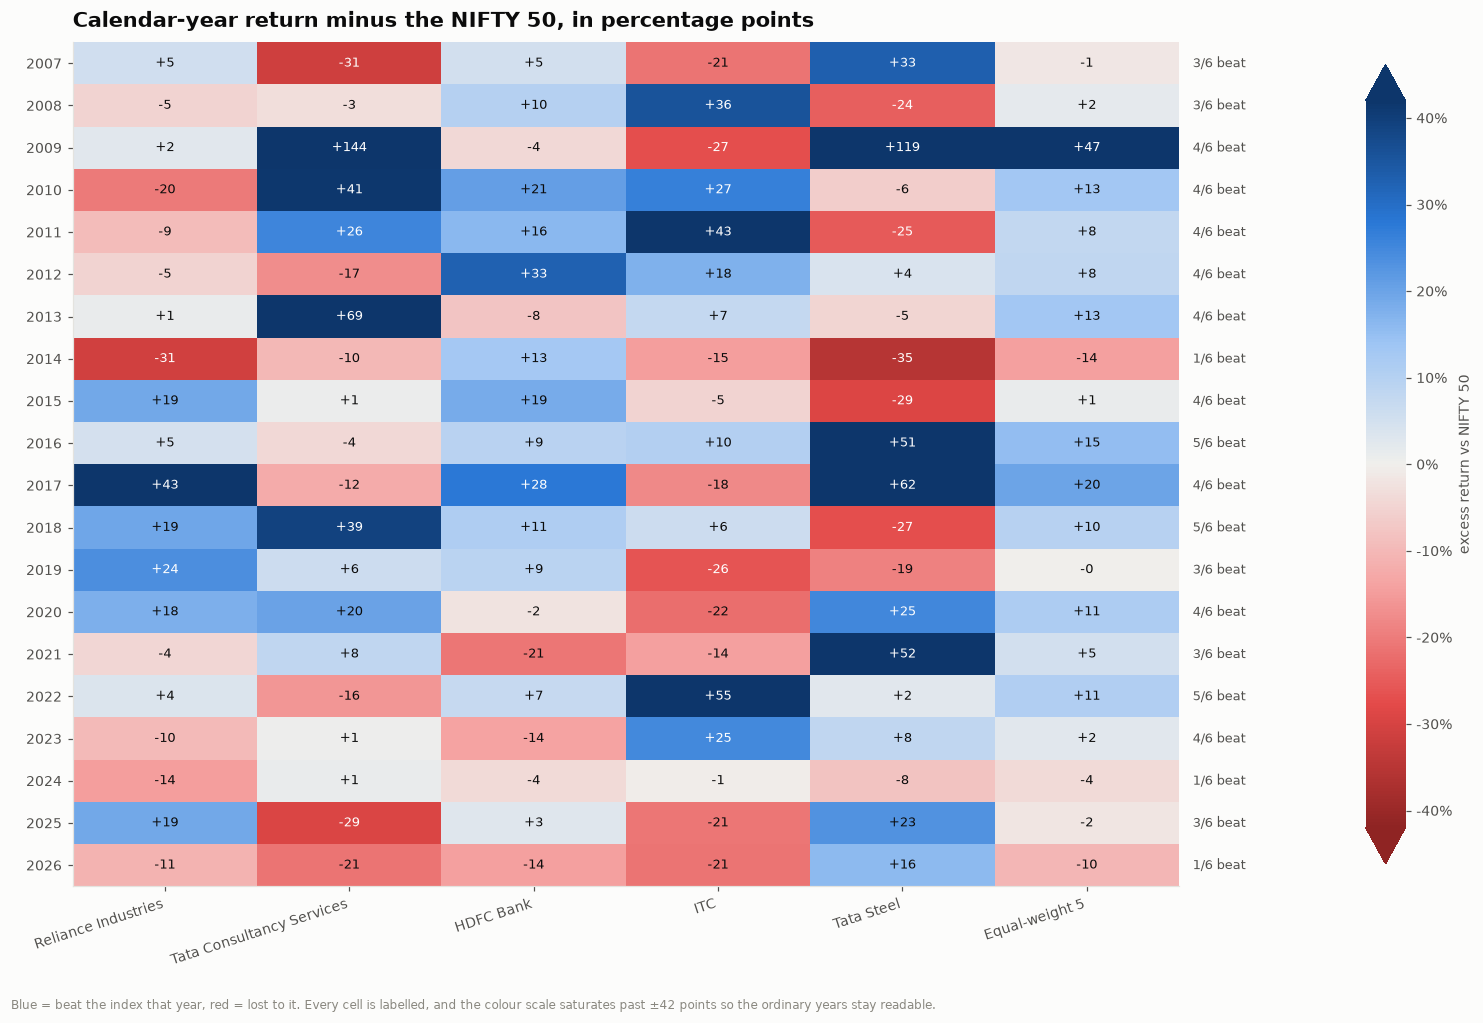

In [21]:
yr_b = {nm: (1 + v).resample("YE").prod() - 1 for nm, v in BH.items()}
yr_n = (1 + rn).resample("YE").prod() - 1
EXC  = pd.DataFrame({nm: v - yr_n for nm, v in yr_b.items()})
EXC.index = EXC.index.year

fig, ax = plt.subplots(figsize=(13.5, 9))
A   = EXC.to_numpy(dtype=float)
# clip the colour scale at the 92nd percentile so 2009's +144 does not wash out every other
# cell; the extremes saturate but every value is printed anyway
lim = float(np.nanpercentile(np.abs(A), 92))
im  = ax.imshow(A, cmap=DIVERGING, norm=TwoSlopeNorm(0, -lim, lim), aspect="auto")
ax.set_xticks(range(EXC.shape[1]), EXC.columns, rotation=18, ha="right")
ax.set_yticks(range(len(EXC)), EXC.index)
ax.grid(visible=False)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        v = A[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v*100:+.0f}", ha="center", va="center", fontsize=8.5,
                    color="#ffffff" if abs(v) > lim * 0.55 else C["ink"])
beat = (EXC > 0).sum(axis=1)
for i, b in enumerate(beat):
    ax.annotate(f"{b}/{EXC.shape[1]} beat", (1.0, i), xycoords=("axes fraction", "data"),
                xytext=(9, 0), textcoords="offset points", va="center", fontsize=8.5,
                color=C["ink_2"], annotation_clip=False)
cb = fig.colorbar(im, ax=ax, pad=0.14, fraction=0.03, extend="both")
cb.ax.yaxis.set_major_formatter(FuncFormatter(pct)); cb.outline.set_visible(False)
cb.set_label("excess return vs NIFTY 50", color=C["ink_2"], fontsize=9)
ax.set_title("Calendar-year return minus the NIFTY 50, in percentage points", loc="left",
             fontsize=14)
finish(fig, "Blue = beat the index that year, red = lost to it. Every cell is labelled, and the "
            "colour scale saturates past ±{:.0f} points so the ordinary years stay readable.".format(lim * 100))
fig.savefig(CHARTS / "13_yearly_excess.png")
plt.show()

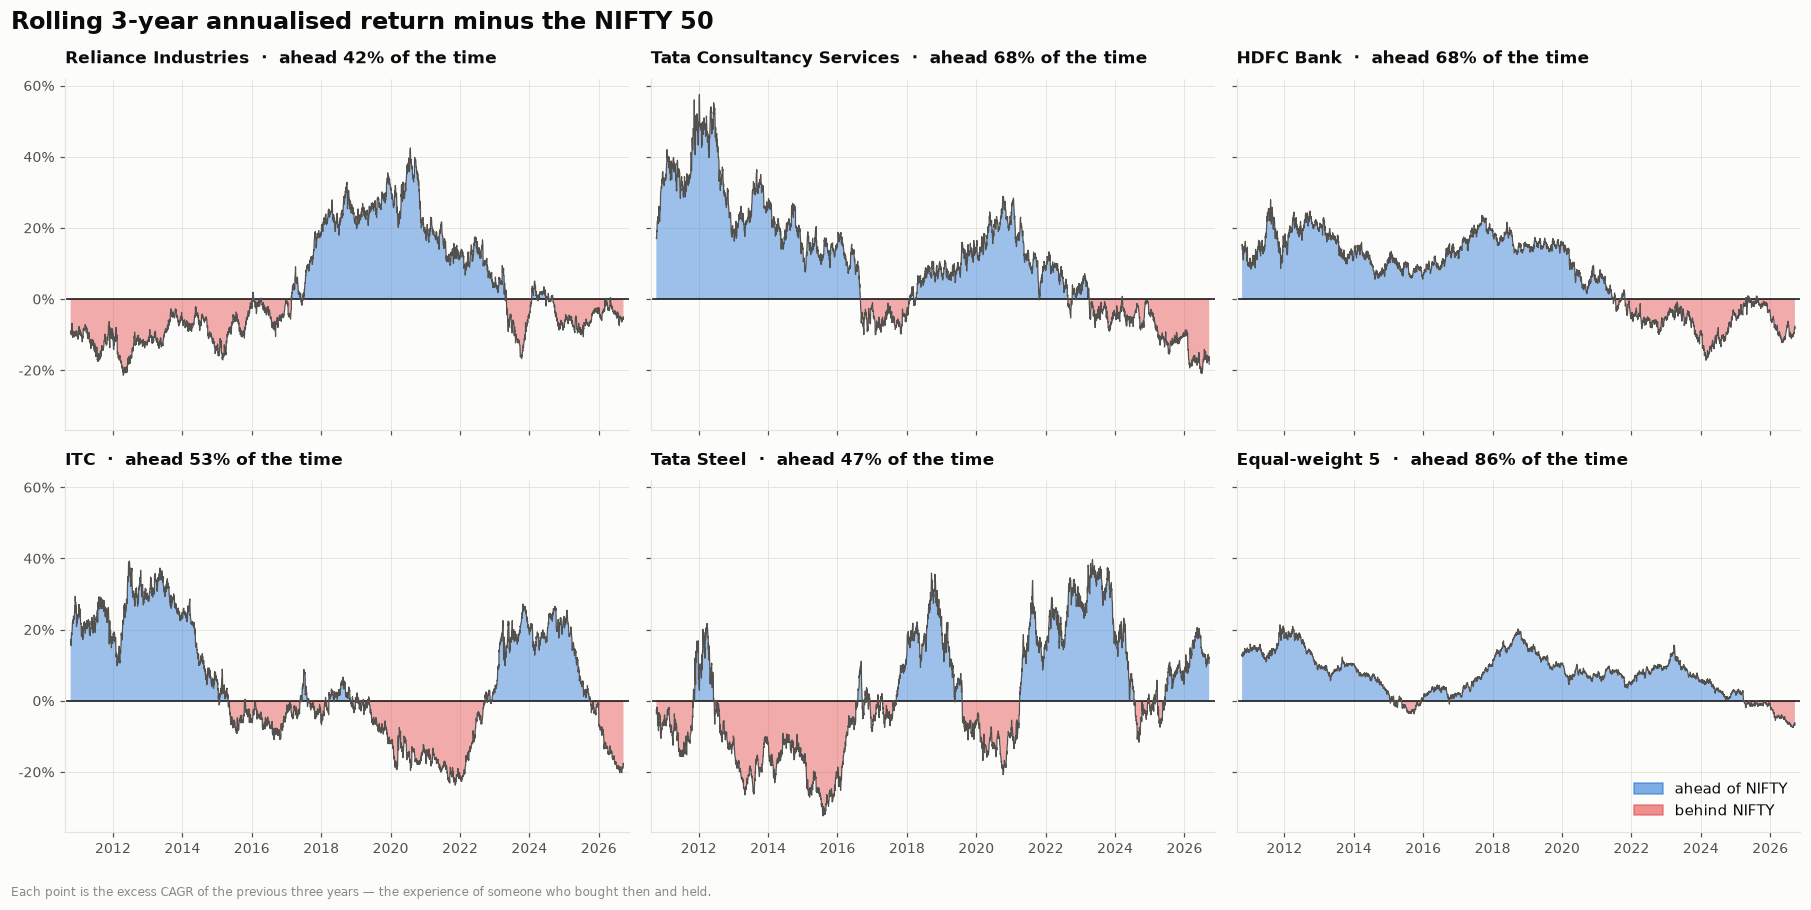

In [22]:
W = 756          # three years of trading days
fig, axes = plt.subplots(2, 3, figsize=(16.5, 8), sharex=True, sharey=True)
ann = lambda e: (e / e.shift(W)) ** (252 / W) - 1
base = ann(eq_n_al)

for ax, nm in zip(axes.ravel(), BH):
    d = (ann(equity(BH[nm])) - base).dropna()
    ax.axhline(0, color=C["ink"], lw=1.0)
    ax.fill_between(d.index, d, 0, where=(d >= 0), color=C["s1_blue"],   alpha=0.45, lw=0)
    ax.fill_between(d.index, d, 0, where=(d < 0),  color=C["s8_red"],    alpha=0.45, lw=0)
    ax.plot(d.index, d, color=C["ink_2"], lw=0.8)
    ax.yaxis.set_major_formatter(FuncFormatter(pct))
    share = float((d > 0).mean())
    ax.set_title(f"{nm}  ·  ahead {share:.0%} of the time", loc="left", fontsize=11)
    ax.margins(x=0.01)
axes.ravel()[-1].legend(handles=[Patch(color=C["s1_blue"], alpha=0.6, label="ahead of NIFTY"),
                                 Patch(color=C["s8_red"],  alpha=0.6, label="behind NIFTY")],
                        ncols=1, loc="lower right")
fig.suptitle("Rolling 3-year annualised return minus the NIFTY 50", x=0.005, ha="left",
             fontsize=16, weight="bold")
finish(fig, "Each point is the excess CAGR of the previous three years — the experience of "
            "someone who bought then and held.")
fig.savefig(CHARTS / "14_rolling_excess.png")
plt.show()

**What to take from section 8.** Read the table and the two heat panels together, not the
cumulative chart alone. Three things are worth checking every time you re-run this:

- **How many of the five actually beat the index, and by how much after adjusting for beta?**
  Excess CAGR flatters any stock with beta > 1 — a name can "beat the index" purely by being a
  levered version of it. The alpha column is the honest one, and `^NSEI` missing its ~1.3%
  dividend yield eats into every positive number here.
- **The equal-weight basket is the fair comparison.** A single stock beating the index tells you
  little, because you did not know in 2007 which one it would be. The equal-weight sleeve is
  what a naive investor in these five names would have got, and that is the number to put
  against the index.
- **Rolling three-year excess is the number you would have lived with.** A stock that wins over
  19 years while spending half of them behind the index is a strategy most people abandon
  before it pays.

## 9 · The screener — find these setups across NSE **and** BSE

The backtest above only tells you whether the rule is worth running. This section is the part
you actually use every morning:

1. **Build the universe.** NSE's official `EQUITY_L.csv` (every listed equity, EQ/BE series) and
   the BSE master scrip list with market caps. De-duplicated on **ISIN** — a dual-listed company
   is screened once, on its NSE line. BSE-only names are kept with a `.BO` ticker.
2. **Filter for tradeability** — market cap ≥ `MIN_MCAP_CR`, median 60-day traded value ≥
   `MIN_TURNOVER_CR`, at least 250 bars of history.
3. **Classify every name** into `GOLDEN` (SMA100 > SMA200) or `DEATH`, with the exact number of
   trading days since the cross.
4. **Rank the fresh golden crosses** on a composite of 200-DMA slope, 6-month momentum,
   how extended price is above the 100-DMA (a penalty), and liquidity.
5. Also surface an **approaching** list — names 0–3% away from crossing with a rising 100-DMA.

In [23]:
UA = {"User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 "
                    "(KHTML, like Gecko) Chrome/124.0 Safari/537.36",
      "Accept-Language": "en-US,en;q=0.9"}

def fetch_nse_list(cache=DATA / "nse_equity_list.csv", max_age_h=24):
    url = "https://nsearchives.nseindia.com/content/equities/EQUITY_L.csv"
    if not cache.exists() or (time.time() - cache.stat().st_mtime) > max_age_h * 3600:
        r = requests.get(url, headers=UA, timeout=30); r.raise_for_status()
        cache.write_bytes(r.content)
    df = pd.read_csv(cache)
    df.columns = [c.strip().upper() for c in df.columns]
    df = df.rename(columns={"NAME OF COMPANY": "NAME", "ISIN NUMBER": "ISIN"})
    for c in ["SYMBOL", "NAME", "SERIES", "ISIN"]:
        df[c] = df[c].astype(str).str.strip()
    return df[df["SERIES"].isin(["EQ", "BE"])][["SYMBOL", "NAME", "SERIES", "ISIN"]]

def fetch_bse_list(cache=DATA / "bse_scrip_list.json", max_age_h=24):
    url = ("https://api.bseindia.com/BseIndiaAPI/api/ListofScripData/w?"
           "Group=&Scripcode=&industry=&segment=Equity&status=Active")
    if not cache.exists() or (time.time() - cache.stat().st_mtime) > max_age_h * 3600:
        r = requests.get(url, headers={**UA, "Referer": "https://www.bseindia.com/"}, timeout=40)
        r.raise_for_status(); cache.write_bytes(r.content)
    df = pd.DataFrame(json.loads(cache.read_text()))
    df["MCAP_CR"] = pd.to_numeric(df["Mktcap"], errors="coerce")
    df["ISIN"]    = df["ISIN_NUMBER"].astype(str).str.strip()
    df["BSE_SYM"] = df["scrip_id"].astype(str).str.strip()
    return df.rename(columns={"Scrip_Name": "NAME", "GROUP": "BSE_GROUP"})[
        ["BSE_SYM", "SCRIP_CD", "NAME", "BSE_GROUP", "ISIN", "MCAP_CR"]]

def build_universe(min_mcap_cr=MIN_MCAP_CR):
    nse, bse = fetch_nse_list(), fetch_bse_list()
    bse = bse.sort_values("MCAP_CR", ascending=False).drop_duplicates("ISIN")
    u = nse.merge(bse[["ISIN", "MCAP_CR", "BSE_GROUP", "SCRIP_CD"]], on="ISIN", how="outer",
                  indicator=True)
    u = u.merge(bse[["ISIN", "BSE_SYM", "NAME"]].rename(columns={"NAME": "BSE_NAME"}),
                on="ISIN", how="left")
    u["exchange"] = np.where(u["SYMBOL"].notna(), "NSE", "BSE")
    u["yahoo"]    = np.where(u["SYMBOL"].notna(), u["SYMBOL"].astype(str) + ".NS",
                                                  u["BSE_SYM"].astype(str) + ".BO")
    u["name"]     = u["NAME"].fillna(u["BSE_NAME"])
    u = u[u["yahoo"].notna() & ~u["yahoo"].str.startswith(("nan", "None"))]
    u = u.drop_duplicates("yahoo")
    keep = u["MCAP_CR"].fillna(0) >= min_mcap_cr
    out = (u.loc[keep, ["yahoo", "name", "exchange", "ISIN", "MCAP_CR", "BSE_GROUP"]]
             .sort_values("MCAP_CR", ascending=False).reset_index(drop=True))
    print(f"NSE listed: {len(nse):,}   BSE active: {len(bse):,}   "
          f"unique companies: {len(u):,}   after ₹{min_mcap_cr:,} cr filter: {len(out):,} "
          f"({(out['exchange']=='NSE').sum()} NSE / {(out['exchange']=='BSE').sum()} BSE-only)")
    return out

UNIV = build_universe()
display(UNIV.head(8).style.hide(axis="index").format({"MCAP_CR": "{:,.0f}"}))

NSE listed: 2,551   BSE active: 5,037   unique companies: 5,163   after ₹1,000 cr filter: 1,549 (1492 NSE / 57 BSE-only)


yahoo,name,exchange,ISIN,MCAP_CR,BSE_GROUP
RELIANCE.NS,Reliance Industries Limited,NSE,INE002A01018,"1,669,848",A
BHARTIARTL.NS,Bharti Airtel Limited,NSE,INE397D01024,"1,164,478",A
HDFCBANK.NS,HDFC Bank Limited,NSE,INE040A01034,"1,123,848",A
ICICIBANK.NS,ICICI Bank Limited,NSE,INE090A01021,"959,775",A
SBIN.NS,State Bank of India,NSE,INE062A01020,"913,661",A
TCS.NS,Tata Consultancy Services Limited,NSE,INE467B01029,"760,160",A
BAJFINANCE.NS,Bajaj Finance Limited,NSE,INE296A01032,"639,406",A
LT.NS,Larsen & Toubro Limited,NSE,INE018A01030,"531,084",A


In [24]:
def bulk_history(tickers, period="3y", chunk=SCREEN_CHUNK,
                 cache=DATA / "screen_prices.pkl", max_age_h=8):
    '''Chunked Yahoo download of Close + Volume for the whole universe.'''
    if cache.exists() and (time.time() - cache.stat().st_mtime) < max_age_h * 3600:
        blob = pickle.loads(cache.read_bytes())
        if set(tickers).issubset(set(blob["close"].columns)):
            print(f"cache hit -> {cache.name}  ({blob['close'].shape[1]} tickers)")
            return blob["close"], blob["volume"]
    closes, vols = [], []
    t0 = time.time()
    for i in range(0, len(tickers), chunk):
        part = tickers[i:i + chunk]
        d = yf.download(part, period=period, auto_adjust=True, progress=False,
                        group_by="column", threads=True)
        if d.empty:
            continue
        closes.append(d["Close"]); vols.append(d["Volume"])
        done = min(i + chunk, len(tickers))
        print(f"\r  {done:>5}/{len(tickers)} tickers   {time.time()-t0:5.0f}s", end="")
    close = pd.concat(closes, axis=1).sort_index()
    vol   = pd.concat(vols,   axis=1).sort_index()
    close = close.loc[:, ~close.columns.duplicated()]
    vol   = vol.loc[:,   ~vol.columns.duplicated()]
    cache.write_bytes(pickle.dumps({"close": close, "volume": vol}))
    print(f"\n  done: {close.shape[1]} tickers, {close.shape[0]} bars, {time.time()-t0:.0f}s")
    return close, vol

symbols = UNIV["yahoo"].tolist()[:MAX_SCREEN] if MAX_SCREEN else UNIV["yahoo"].tolist()
CL, VL = bulk_history(symbols)

cache hit -> screen_prices.pkl  (1549 tickers)


In [25]:
def scan(close, vol, universe, fast=FAST, slow=SLOW,
         min_turnover_cr=MIN_TURNOVER_CR, min_bars=None):
    '''Current 100/200-DMA state, days since the cross, and a quality score, per symbol.'''
    min_bars = (slow + 50) if min_bars is None else min_bars
    close = close.reindex(columns=[c for c in universe["yahoo"] if c in close.columns])
    vol   = vol.reindex(columns=close.columns)
    close = close.loc[:, close.notna().sum() >= min_bars]
    vol   = vol.reindex(columns=close.columns)

    # The frame is a union calendar of every ticker, so a stock that missed one
    # session carries a NaN -- and a single NaN anywhere inside a 200-bar window
    # kills the whole rolling mean. Pad small gaps; drop anything stale for a week.
    live  = close.tail(5).notna().any()
    close = close.loc[:, live]
    vol   = vol.reindex(columns=close.columns)
    cl    = close.ffill(limit=5)

    ma_f = cl.rolling(fast, min_periods=fast).mean()
    ma_s = cl.rolling(slow, min_periods=slow).mean()
    state = (ma_f > ma_s)
    state = state.where(ma_s.notna())

    last = state.iloc[-1]
    # days since the most recent flip, per column
    flip = state.ne(state.shift()) & state.notna() & state.shift().notna()
    idx  = pd.Series(np.arange(len(state)), index=state.index)
    since = {}
    for c in state.columns:
        f = idx[flip[c].fillna(False)]
        since[c] = int(idx.iloc[-1] - f.iloc[-1]) if len(f) else np.nan
    since = pd.Series(since)

    px      = cl.iloc[-1]
    turn_cr = (close * vol).tail(60).median() / 1e7            # ₹ crore per day
    spread  = ma_f.iloc[-1] / ma_s.iloc[-1] - 1.0
    slope   = ma_s.iloc[-1] / ma_s.shift(20).iloc[-1] - 1.0    # 200-DMA slope, 20 bars
    ext     = px / ma_f.iloc[-1] - 1.0                         # stretch above the 100-DMA
    mom6    = px / cl.shift(126).iloc[-1] - 1.0
    mom12   = px / cl.shift(252).iloc[-1] - 1.0
    vol_ann = (cl.pct_change().tail(252).std() * np.sqrt(252))

    out = pd.DataFrame({
        "price": px, "sma100": ma_f.iloc[-1], "sma200": ma_s.iloc[-1],
        "spread": spread, "state": np.where(last, "GOLDEN", "DEATH"),
        "days_since_cross": since, "sma200_slope_20d": slope, "ext_vs_sma100": ext,
        "ret_6m": mom6, "ret_12m": mom12, "ann_vol": vol_ann, "turnover_cr": turn_cr,
    })
    meta = universe.set_index("yahoo")[["name", "exchange", "MCAP_CR"]]
    out = out.join(meta).dropna(subset=["price", "spread"])
    out = out[out["turnover_cr"] >= min_turnover_cr]
    out["days_since_cross"] = out["days_since_cross"].astype("Float64")

    z = lambda s: (s - s.mean()) / s.std(ddof=0)
    g = out[out["state"] == "GOLDEN"].copy()
    g["score"] = (1.0 * z(g["sma200_slope_20d"]) + 0.8 * z(g["ret_6m"])
                  - 0.6 * z(g["ext_vs_sma100"].abs()) + 0.4 * z(np.log1p(g["turnover_cr"]))
                  - 0.3 * z(g["ann_vol"]))
    out = out.join(g["score"])
    return out.sort_values(["state", "score"], ascending=[True, False])

SCAN = scan(CL, VL, UNIV)
SCAN.to_csv(OUT / f"dma_scan_{datetime.today():%Y%m%d}.csv")

FRESH = SCAN[(SCAN["state"] == "GOLDEN") &
             (SCAN["days_since_cross"] <= FRESH_DAYS)].sort_values("score", ascending=False)
APPROACH = SCAN[(SCAN["state"] == "DEATH") & SCAN["spread"].between(-0.03, 0) &
                (SCAN["sma200_slope_20d"] > 0)].sort_values("spread", ascending=False)

print(f"downloaded {CL.shape[1]:,} tickers -> {len(SCAN):,} passed the history + liquidity filters")
print(f"scanned {len(SCAN):,} tradeable stocks  "
      f"({(SCAN['state']=='GOLDEN').sum():,} golden / {(SCAN['state']=='DEATH').sum():,} death)")
print(f"fresh golden crosses (<= {FRESH_DAYS} bars): {len(FRESH)}   |   about to cross: {len(APPROACH)}")

cols = ["name", "exchange", "price", "sma100", "sma200", "spread", "days_since_cross",
        "sma200_slope_20d", "ret_6m", "turnover_cr", "MCAP_CR", "score"]
f2 = {"price": "{:,.1f}", "sma100": "{:,.1f}", "sma200": "{:,.1f}", "spread": "{:+.2%}",
      "days_since_cross": "{:,.0f}", "sma200_slope_20d": "{:+.2%}", "ret_6m": "{:+.1%}",
      "turnover_cr": "{:,.1f}", "MCAP_CR": "{:,.0f}", "score": "{:.2f}"}
display(FRESH[cols].head(20).style.format(f2)
        .set_caption(f"Fresh golden crosses — ranked buy candidates ({datetime.today():%d %b %Y})"))
display(APPROACH[cols[:-1]].head(12).style.format({k: v for k, v in f2.items() if k != 'score'})
        .set_caption("Approaching a golden cross — watchlist"))

downloaded 1,549 tickers -> 1,258 passed the history + liquidity filters
scanned 1,258 tradeable stocks  (834 golden / 424 death)
fresh golden crosses (<= 15 bars): 66   |   about to cross: 16


,name,exchange,price,sma100,sma200,spread,days_since_cross,sma200_slope_20d,ret_6m,turnover_cr,MCAP_CR,score
ICICIBANK.NS,ICICI Bank Limited,NSE,"1,338.9","1,356.4","1,346.2",+0.75%,15,+0.33%,+8.4%,"1,511.4","959,775",1.16
TECHM.NS,Tech Mahindra Limited,NSE,"1,537.1","1,500.6","1,491.2",+0.63%,8,+1.00%,+13.9%,331.5,"150,029",0.72
ETERNAL.NS,ETERNAL LIMITED,NSE,326.9,284.4,274.6,+3.59%,15,+0.76%,+40.7%,853.5,"315,132",0.66
COFORGE.NS,Coforge Limited,NSE,"1,841.0","1,585.6","1,518.4",+4.42%,10,+0.46%,+69.4%,412.7,"77,954",0.61
IDFCFIRSTB.NS,IDFC First Bank Limited,NSE,85.9,79.0,77.3,+2.23%,11,+0.73%,+36.9%,118.5,"74,448",0.35
IIFL.NS,IIFL Finance Limited,NSE,600.2,552.5,537.3,+2.82%,11,+1.49%,+26.9%,114.0,"25,527",0.16
LICI.NS,Life Insurance Corporation Of India,NSE,407.7,410.9,407.7,+0.78%,14,-0.72%,+7.4%,201.1,"520,737",0.12
POLICYBZR.NS,PB Fintech Limited,NSE,"1,743.0","1,676.6","1,649.7",+1.63%,14,+0.05%,+16.4%,195.7,"80,509",0.10
DLF.NS,DLF Limited,NSE,644.3,629.4,622.1,+1.18%,8,-1.07%,+20.7%,197.0,"156,205",0.03
MAXHEALTH.NS,Max Healthcare Institute Limited,NSE,"1,049.3","1,046.4","1,034.6",+1.15%,14,-1.09%,+9.0%,183.8,"102,684",0.02


,name,exchange,price,sma100,sma200,spread,days_since_cross,sma200_slope_20d,ret_6m,turnover_cr,MCAP_CR
SARDAEN.NS,Sarda Energy & Minerals Limited,NSE,506.0,519.2,519.3,-0.01%,0,+0.13%,-0.2%,13.6,"17,816"
JINDALSTEL.NS,JINDAL STEEL LIMITED,NSE,"1,119.5","1,130.5","1,131.0",-0.04%,0,+0.81%,-5.5%,93.3,"114,745"
HINDZINC.NS,Hindustan Zinc Limited,NSE,596.0,578.6,580.3,-0.29%,2,+2.15%,+17.9%,227.7,"247,266"
M&MFIN.NS,Mahindra & Mahindra Financial Services Limited,NSE,353.3,337.1,338.6,-0.44%,63,+1.11%,+17.2%,84.0,"49,198"
VRLLOG.NS,VRL Logistics Limited,NSE,293.6,259.2,260.6,-0.53%,172,+0.97%,+21.6%,4.0,"5,123"
ANURAS.NS,Anupam Rasayan India Limited,NSE,"1,207.7","1,273.0","1,280.0",-0.55%,5,+0.63%,-3.6%,30.7,"13,726"
NTPC.NS,NTPC Limited,NSE,323.6,352.2,354.2,-0.56%,2,+0.28%,-14.1%,273.2,"314,172"
CRISIL.NS,Crisil Limited,NSE,"4,577.5","4,272.4","4,299.6",-0.63%,195,+0.33%,+15.8%,21.7,"33,471"
SMCGLOBAL.NS,SMC Global Securities Limited,NSE,80.9,73.5,74.0,-0.63%,77,+2.70%,+26.0%,3.6,"1,695"
INDIANB.NS,Indian Bank,NSE,839.8,841.7,850.0,-0.97%,32,+0.18%,-2.4%,125.4,"113,792"


### 9.1 · What the whole market looks like right now

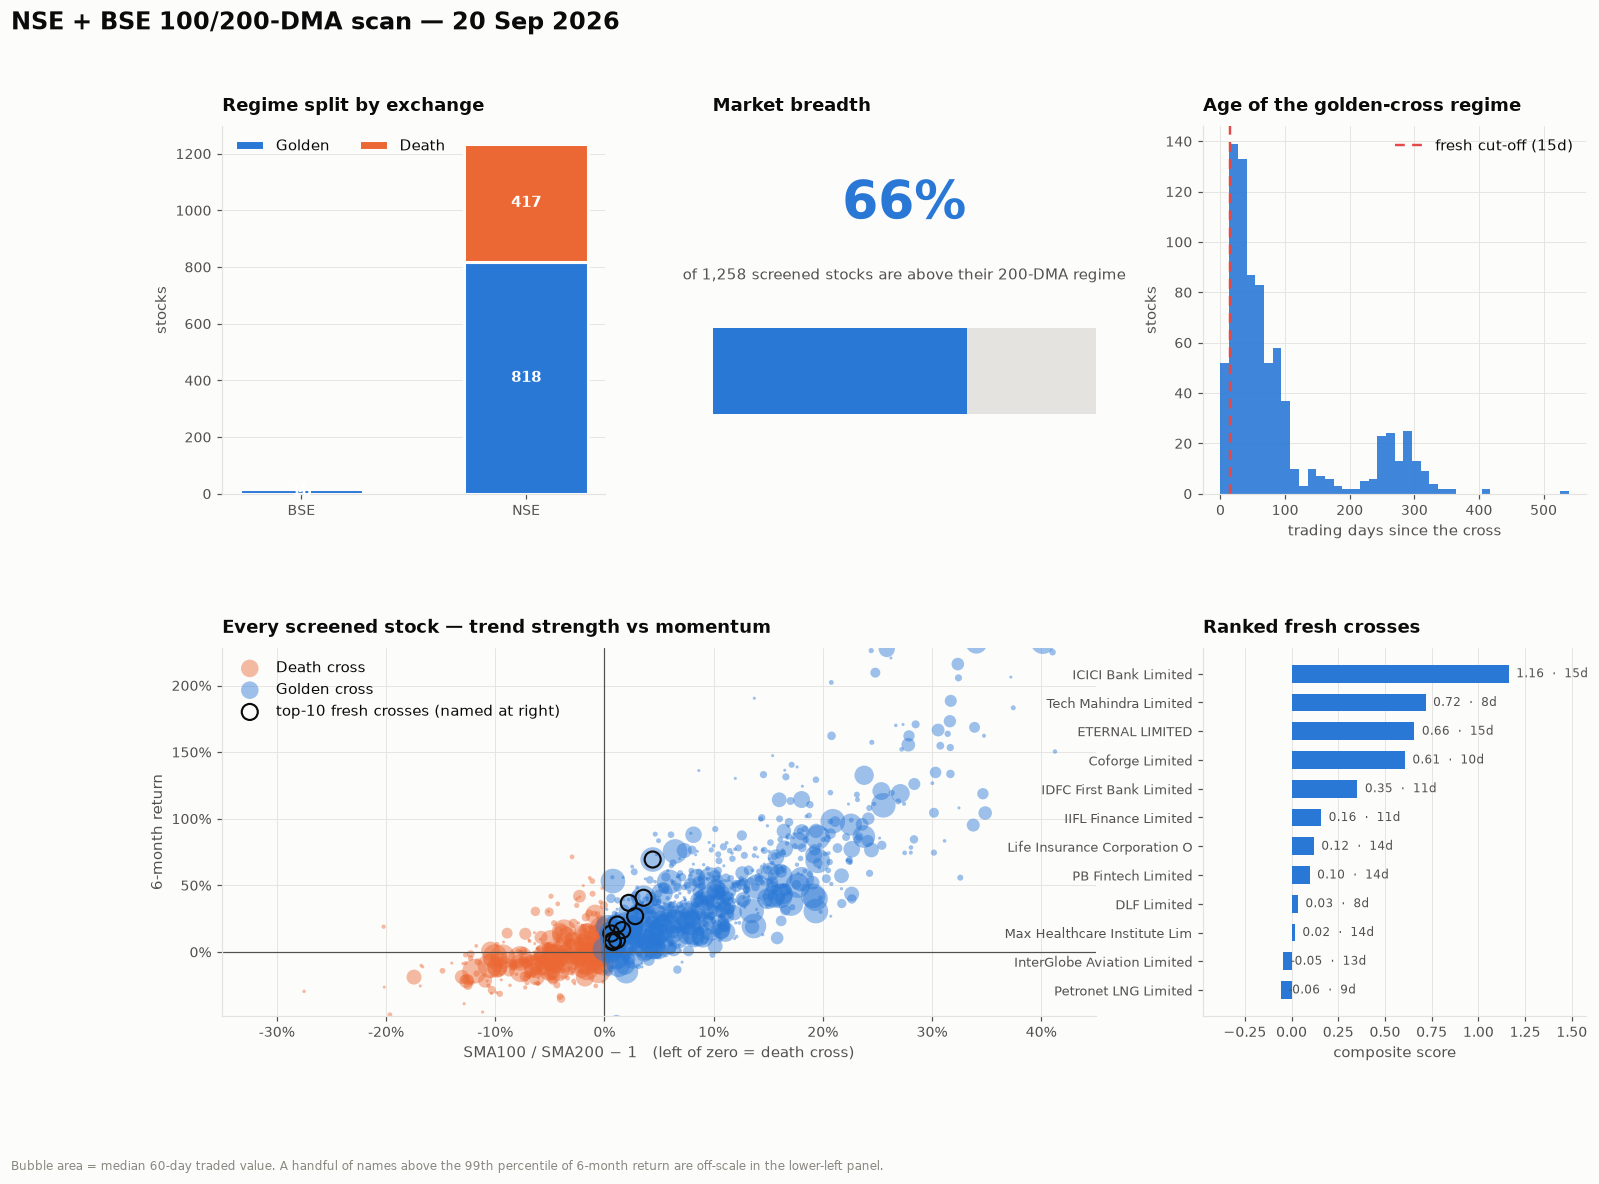

In [26]:
fig = plt.figure(figsize=(16, 10.5))
gs  = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.28)

# -- regime split by exchange ------------------------------------------------
ax = fig.add_subplot(gs[0, 0])
tab = pd.crosstab(SCAN["exchange"], SCAN["state"]).reindex(columns=["GOLDEN", "DEATH"]).fillna(0)
bot = np.zeros(len(tab))
for st, colr in [("GOLDEN", C["s1_blue"]), ("DEATH", C["s2_orange"])]:
    ax.bar(tab.index, tab[st], bottom=bot, color=colr, label=st.title(), width=0.55,
           edgecolor=C["surface"], linewidth=2)
    for i, v in enumerate(tab[st]):
        if v: ax.text(i, bot[i] + v / 2, f"{int(v)}", ha="center", va="center",
                      color="#ffffff", fontsize=10, weight="bold")
    bot += tab[st].to_numpy()
ax.set_title("Regime split by exchange", loc="left")
ax.set_ylabel("stocks"); ax.legend(ncols=2); ax.grid(axis="x", visible=False)

# -- breadth gauge -----------------------------------------------------------
ax = fig.add_subplot(gs[0, 1])
share = (SCAN["state"] == "GOLDEN").mean()
ax.barh([0], [1], color=C["grid"], height=0.42)
ax.barh([0], [share], color=C["s1_blue"], height=0.42)
ax.text(0.5, 0.75, f"{share:.0%}", ha="center", fontsize=34, weight="bold", color=C["s1_blue"])
ax.text(0.5, 0.45, f"of {len(SCAN):,} screened stocks are above their 200-DMA regime",
        ha="center", fontsize=10, color=C["ink_2"])
ax.set_xlim(0, 1); ax.set_ylim(-0.6, 1.2); ax.axis("off")
ax.set_title("Market breadth", loc="left")

# -- how old is the trend ----------------------------------------------------
ax = fig.add_subplot(gs[0, 2])
d = SCAN.loc[SCAN["state"] == "GOLDEN", "days_since_cross"].dropna()
ax.hist(d, bins=40, color=C["s1_blue"], alpha=0.9)
ax.axvline(FRESH_DAYS, color=C["s8_red"], lw=1.6, ls=(0, (4, 3)),
           label=f"fresh cut-off ({FRESH_DAYS}d)")
ax.set_title("Age of the golden-cross regime", loc="left")
ax.set_xlabel("trading days since the cross"); ax.set_ylabel("stocks"); ax.legend()

# -- spread vs momentum ------------------------------------------------------
ax = fig.add_subplot(gs[1, :2])
g = SCAN[SCAN["state"] == "GOLDEN"]
b = SCAN[SCAN["state"] == "DEATH"]
ax.axhline(0, color=C["ink_2"], lw=0.8); ax.axvline(0, color=C["ink_2"], lw=0.8)
ax.scatter(b["spread"], b["ret_6m"], s=np.clip(b["turnover_cr"], 4, 260), color=C["s2_orange"],
           alpha=0.45, edgecolor="none", label="Death cross")
ax.scatter(g["spread"], g["ret_6m"], s=np.clip(g["turnover_cr"], 4, 260), color=C["s1_blue"],
           alpha=0.45, edgecolor="none", label="Golden cross")
top = FRESH.head(10)
ax.scatter(top["spread"], top["ret_6m"], s=110, facecolor="none", edgecolor=C["ink"], lw=1.4,
           label="top-10 fresh crosses (named at right)")
ax.set_xlim(-0.35, 0.45)
ax.set_ylim(max(-1.0, SCAN["ret_6m"].quantile(0.005) - 0.1),
            min(3.0, SCAN["ret_6m"].quantile(0.99) + 0.1))
ax.xaxis.set_major_formatter(FuncFormatter(pct)); ax.yaxis.set_major_formatter(FuncFormatter(pct))
ax.set_xlabel("SMA100 / SMA200 − 1   (left of zero = death cross)")
ax.set_ylabel("6-month return")
ax.set_title("Every screened stock — trend strength vs momentum", loc="left")
ax.legend(loc="upper left")

# -- leaderboard -------------------------------------------------------------
ax = fig.add_subplot(gs[1, 2])
lead = FRESH.head(12).iloc[::-1]
if len(lead):
    ax.barh(np.arange(len(lead)), lead["score"], color=C["s1_blue"], height=0.62)
    ax.set_yticks(np.arange(len(lead)), [str(n)[:28] for n in lead["name"]], fontsize=8.5)
    for i, (v, dd) in enumerate(zip(lead["score"], lead["days_since_cross"])):
        ax.annotate(f"{v:.2f}  ·  {dd:.0f}d", (v, i), xytext=(5, 0), textcoords="offset points",
                    va="center", fontsize=8, color=C["ink_2"])
    ax.margins(x=0.34)
else:
    ax.text(0.5, 0.5, "no fresh crosses today", ha="center", color=C["ink_2"])
ax.grid(axis="y", visible=False)
ax.set_title("Ranked fresh crosses", loc="left"); ax.set_xlabel("composite score")

fig.suptitle(f"NSE + BSE 100/200-DMA scan — {datetime.today():%d %b %Y}",
             x=0.005, ha="left", fontsize=16, weight="bold")
finish(fig, "Bubble area = median 60-day traded value. A handful of names above the 99th percentile "
            "of 6-month return are off-scale in the lower-left panel.")
fig.savefig(CHARTS / "09_screener.png")
plt.show()

### 9.2 · Drill into any screened name

`inspect(symbol)` runs the exact same engine and signal chart on a candidate, so a screener hit
can be checked against its own history before you touch it.

demo drill-down on the top-ranked fresh cross: ICICIBANK.NS | ICICI Bank Limited


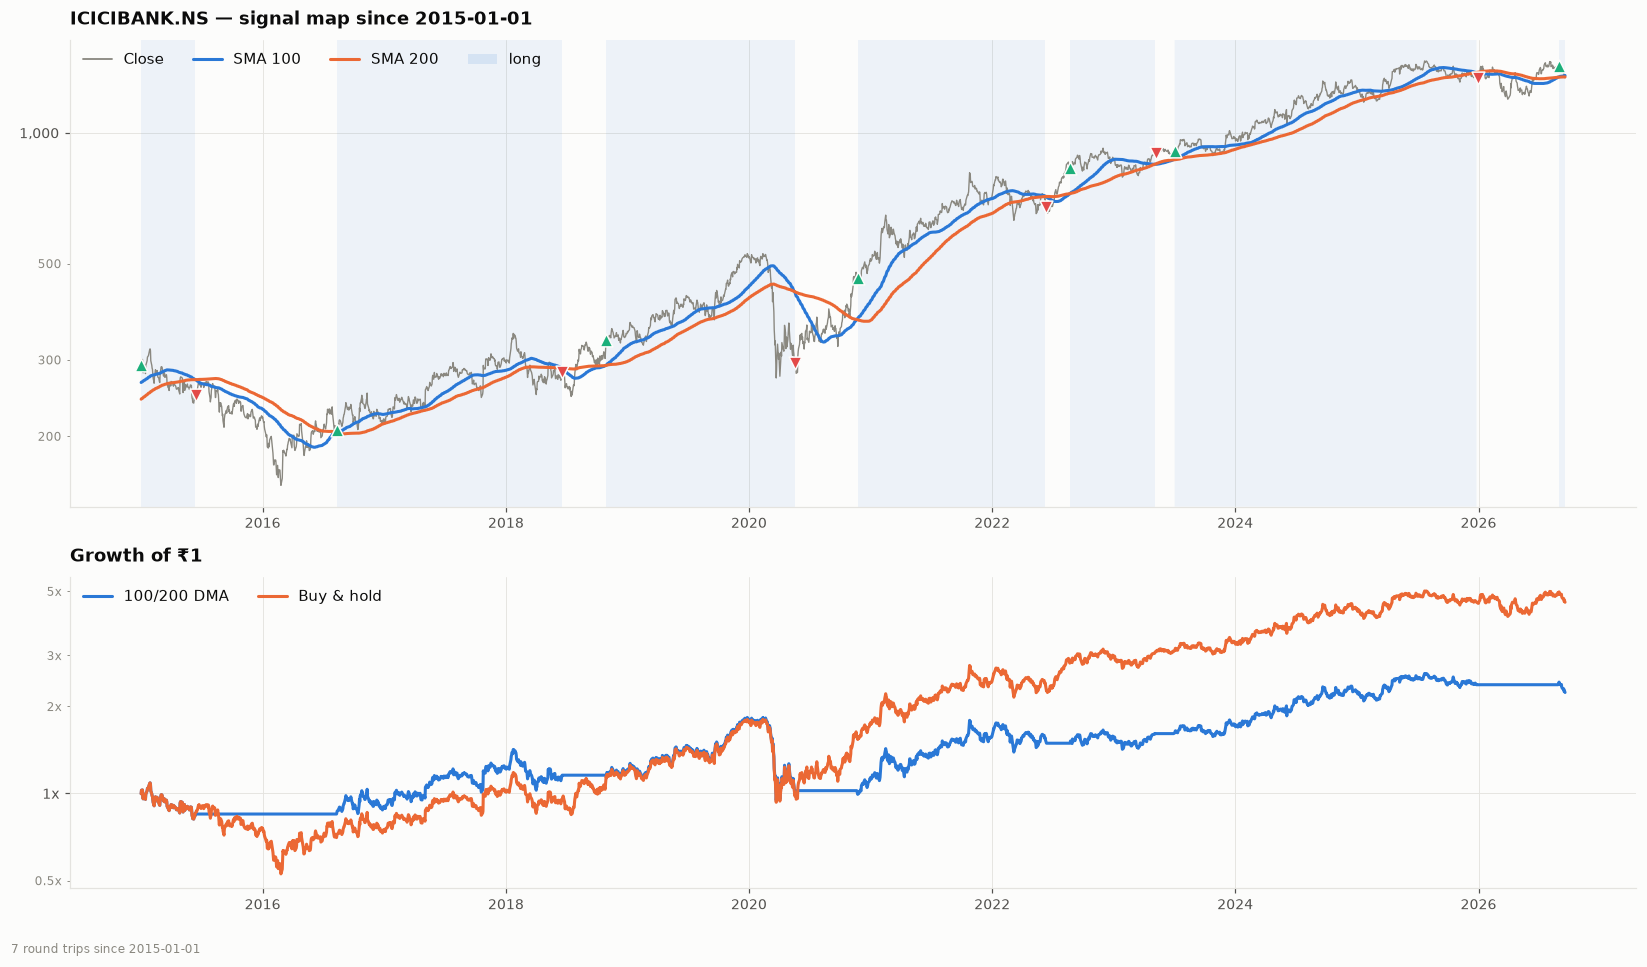

,100/200 DMA,Buy & hold
Total return,1.234,3.582
CAGR,0.072,0.142
Ann. vol,0.250,0.299
Sharpe,0.165,0.391
Sortino,0.198,0.566
Max DD,-0.483,-0.515
Calmar,0.150,0.275
Longest DD (d),1030.000,732.000
Best month,0.174,0.245
Worst month,-0.349,-0.349


In [27]:
def inspect(symbol, start="2015-01-01"):
    d = yf.download(symbol, start="2010-01-01", auto_adjust=True, progress=False,
                    group_by="column")
    d = pd.DataFrame({k: d[k][symbol] for k in ["Open", "High", "Low", "Close", "Volume"]}).dropna()
    ma_f, ma_s, sig, pos = signal_and_position(d)
    r_s, _ = strategy_returns(d, pos)
    r_b    = buy_hold_returns(d)
    w = slice(start, None)
    rs, rb = r_s.loc[w], r_b.loc[w]
    es, eb = equity(rs), equity(rb)
    tr = trade_ledger(d, pos, start=start)
    st = pd.DataFrame({"100/200 DMA": perf_stats(rs, exposure=pos.loc[w].fillna(0).mean()),
                       "Buy & hold":  perf_stats(rb, exposure=1.0)})

    fig, (a1, a2) = plt.subplots(2, 1, figsize=(15, 8.5), height_ratios=[1.5, 1])
    dd = d.loc[w]
    a1.fill_between(dd.index, 0, 1, where=(pos.loc[w].fillna(0) == 1),
                    transform=a1.get_xaxis_transform(), color=C["s1_blue"], alpha=0.07, lw=0)
    a1.plot(dd.index, dd["Close"], color=C["ink_muted"], lw=0.9)
    a1.plot(ma_f.loc[w].index, ma_f.loc[w], color=C["s1_blue"], label=f"SMA {FAST}")
    a1.plot(ma_s.loc[w].index, ma_s.loc[w], color=C["s2_orange"], label=f"SMA {SLOW}")
    if len(tr):
        a1.scatter(tr["entry"], tr["entry_px"], marker="^", s=70, color=C["good"],
                   edgecolor=C["surface"], zorder=5)
        cl = tr[~tr["open_trade"]]
        a1.scatter(cl["exit"], cl["exit_px"], marker="v", s=70, color=C["bad"],
                   edgecolor=C["surface"], zorder=5)
    log_money(a1, unit="rs")
    a1.set_title(f"{symbol} — signal map since {start}", loc="left")
    a1.legend(handles=[Line2D([], [], color=C["ink_muted"], lw=1.2, label="Close"),
                       Line2D([], [], color=C["s1_blue"], lw=2, label=f"SMA {FAST}"),
                       Line2D([], [], color=C["s2_orange"], lw=2, label=f"SMA {SLOW}"),
                       Patch(facecolor=C["s1_blue"], alpha=0.12, label="long")], ncols=4)
    a2.plot(es.index, es, color=C["s1_blue"], label="100/200 DMA")
    a2.plot(eb.index, eb, color=C["s2_orange"], label="Buy & hold")
    log_money(a2)
    a2.set_title("Growth of ₹1", loc="left"); a2.legend(ncols=2)
    finish(fig, f"{len(tr)} round trips since {start}")
    plt.show()
    display(st.style.format(precision=3).set_caption(symbol))
    return st, tr

if len(FRESH):
    _demo = FRESH.index[0]
    print("demo drill-down on the top-ranked fresh cross:", _demo, "|", FRESH.iloc[0]["name"])
    _ = inspect(_demo)
else:
    _ = inspect("RELIANCE.NS")

### 9.3 · Daily use

```python
UNIV  = build_universe()                 # refresh the NSE + BSE master lists
CL, V = bulk_history(UNIV["yahoo"].tolist())
SCAN  = scan(CL, V, UNIV)
SCAN[(SCAN.state == "GOLDEN") & (SCAN.days_since_cross <= 15)].head(25)
```

Sells are the same table read the other way — anything you hold that has flipped to `DEATH`
(`SCAN.loc["YOURSTOCK.NS", "state"]`) is an exit at the next open. Results are written to
`output/dma_scan_<date>.csv` so you can diff today's file against yesterday's and see exactly
which names changed regime overnight.

## 10 · What this backtest does *not* prove

Read this before sizing anything.

1. **Five survivors.** These five are large, liquid companies that are still around in 2026.
   That is survivorship bias baked into the sample — the screener section exists precisely
   because a live universe is the honest test. Re-run the study on a random 30 names drawn
   from `UNIV` before believing the numbers.
2. **A crossover system is a long-volatility bet on trends.** It wins when moves are large and
   persistent (2008, 2020) and bleeds in chop via whipsaws. Fifteen-odd round trips per stock
   over nineteen years is a *tiny* sample — the difference between this rule and buy & hold is
   decided by a handful of exits.
3. **Costs are modelled, impact is not.** 10 bps per side is realistic for a liquid large cap,
   optimistic for anything in the BSE tail. There is no STCG/LTCG tax in these numbers, and for
   a rule that holds for months at a time tax treatment materially changes the ranking.
4. **Yahoo's adjusted prices** handle splits and dividends but are known to be patchy on Indian
   corporate actions, demergers and ticker changes (Tata Motors' 2025 demerger is a live
   example). Cross-check any name before trading it.
5. **No parameter search was run, on purpose.** 100/200 was given, not optimised. If you now go
   hunting for the best pair on this same data, whatever you find is mostly curve fit — test it
   on stocks that were not used to pick it.
6. **Flat means flat.** `CASH_YIELD = 0`, so the strategy earns nothing for the ~25–30% of the
   time it sits out. Set it to ~6% (liquid fund) to see how much of the gap that closes.